# 03 - Perfilado del integrado preliminar canónico

**Dominio:** bibliográfico/académico.  
**Objetivo:** diagnosticar la calidad del archivo `integrado_preliminar_canonico.csv` sin limpiar, eliminar, deduplicar, fusionar ni exportar una nueva base.

Esta libreta:

- usa únicamente `integrado_preliminar_canonico.csv`;
- no usa archivos de trazabilidad;
- crea una columna auxiliar `fuente_inferida` solo dentro de la libreta;
- genera gráficas dentro del notebook y las guarda como `.png`;
- no genera reportes finales en `.xlsx`, `.md` ni reglas de limpieza.

## 1. Configuración de rutas

In [1]:
from pathlib import Path
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

# Raíz del proyecto
RUTA_PROYECTO = Path(r"C:\Users\hazar\Desktop\PROYECTO")

# Archivo de entrada único para este perfilado
RUTA_ENTRADA = (
    RUTA_PROYECTO
    / "02_modelo canonico"
    / "03_union"
    / "integrado_preliminar_canonico.csv"
)

# Ubicación esperada de esta libreta
RUTA_LIBRETA = (
    RUTA_PROYECTO
    / "notebooks"
    / "03_perfilado_integrado_preliminar.ipynb"
)

# Carpeta de salida para gráficas
CARPETA_GRAFICAS = RUTA_PROYECTO / "10_visualizaciones" / "perfilado"
CARPETA_GRAFICAS.mkdir(parents=True, exist_ok=True)

COLUMNAS_CANONICAS = [
    "indice",
    "Titulo",
    "Año",
    "Autor_norm",
    "Afiliacion1",
    "Afiliacion2",
    "ISBN",
    "ISSN",
    "Doi",
    "URL",
    "Area",
    "Subarea",
    "Keywords",
    "Abstract",
]

AREAS_VALIDAS = {"ISBD", "CC", "IA", "TC", "SIAV", "RS"}
ANIOS_VALIDOS = {"2024", "2025"}

# Umbral práctico para detectar abstracts demasiado cortos.
# Se puede ajustar después de revisar los resultados.
UMBRAL_ABSTRACT_CORTO = 100

print("Archivo de entrada:", RUTA_ENTRADA)
print("Ubicación esperada de la libreta:", RUTA_LIBRETA)
print("Carpeta de gráficas:", CARPETA_GRAFICAS)

Archivo de entrada: C:\Users\hazar\Desktop\PROYECTO\02_modelo canonico\03_union\integrado_preliminar_canonico.csv
Ubicación esperada de la libreta: C:\Users\hazar\Desktop\PROYECTO\notebooks\03_perfilado_integrado_preliminar.ipynb
Carpeta de gráficas: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado


### Funciones auxiliares

In [2]:
VALORES_VACIOS = {
    "",
    "nan",
    "none",
    "null",
    "na",
    "n/a",
    "s/d",
    "sd",
    "sin dato",
    "sin datos",
    "-",
    "--",
}

def es_vacio(valor):
    """Devuelve True si el valor es nulo, vacío o un marcador común de dato faltante."""
    if pd.isna(valor):
        return True
    return str(valor).strip().lower() in VALORES_VACIOS


def limpiar_espacios(texto):
    """Convierte a texto y normaliza espacios consecutivos."""
    if pd.isna(texto):
        return ""
    return re.sub(r"\s+", " ", str(texto)).strip()


def longitud_texto(valor):
    """Longitud de texto; los valores vacíos o marcadores de faltante cuentan como 0."""
    if es_vacio(valor):
        return 0
    return len(str(valor).strip())


def normalizar_texto_basico(texto):
    """
    Normalización simple para comparar títulos y autores:
    minúsculas, sin acentos, sin signos y con espacios simples.
    """
    if es_vacio(texto):
        return ""
    texto = limpiar_espacios(texto).lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"[^a-z0-9]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def normalizar_anio(valor):
    """Normaliza año como texto de cuatro dígitos cuando es posible."""
    if es_vacio(valor):
        return ""
    texto = limpiar_espacios(valor)
    if re.fullmatch(r"\d{4}\.0", texto):
        texto = texto[:4]
    return texto


def inferir_fuente_desde_indice(indice):
    """
    Infiere la fuente usando solo el prefijo de indice.
    Esta inferencia es auxiliar y no modifica ni exporta el archivo original.
    """
    if es_vacio(indice):
        return "SIN_INDICE"
    texto = limpiar_espacios(indice).upper()
    prefijos = {
        "PROQUEST_": "PROQUEST",
        "SCOPUS_": "SCOPUS",
        "EBSCO_": "EBSCO",
        "IEEE_": "IEEE",
        "ACM_": "ACM",
        "WOS_": "WOS",
        "EV_": "EV",
        "SD_": "SD",
    }
    for prefijo, fuente in prefijos.items():
        if texto.startswith(prefijo):
            return fuente
    return "OTRA"


def normalizar_doi(valor):
    """Quita prefijos comunes para revisar el patrón DOI."""
    if es_vacio(valor):
        return ""
    texto = limpiar_espacios(valor)
    texto = re.sub(r"^doi:\s*", "", texto, flags=re.IGNORECASE)
    texto = re.sub(r"^https?://(dx\.)?doi\.org/", "", texto, flags=re.IGNORECASE)
    texto = texto.strip().strip(".,;")
    return texto


def validar_doi(valor):
    """
    Valida formato DOI básico.
    Los valores vacíos se consideran 'no sospechosos' aquí porque la ausencia
    se mide por separado en completitud.
    """
    doi = normalizar_doi(valor)
    if not doi:
        return True
    patron = r"10\.\d{4,9}/[-._;()/:A-Z0-9]+"
    return bool(re.fullmatch(patron, doi, flags=re.IGNORECASE))


def _validar_issn_uno(valor):
    """Valida un ISSN individual con dígito verificador."""
    limpio = re.sub(r"[^0-9Xx]", "", str(valor))
    if len(limpio) != 8:
        return False
    total = 0
    for i, caracter in enumerate(limpio.upper()):
        digito = 10 if caracter == "X" else int(caracter)
        total += digito * (8 - i)
    return total % 11 == 0


def validar_issn(valor):
    """
    Valida ISSN. Si hay varios candidatos en la celda, acepta la celda si
    al menos uno tiene formato y dígito verificador válidos.
    """
    if es_vacio(valor):
        return True
    texto = limpiar_espacios(valor)
    candidatos = re.findall(r"\d{4}[- ]?\d{3}[\dXx]", texto)
    if not candidatos:
        candidatos = [texto]
    return any(_validar_issn_uno(candidato) for candidato in candidatos)


def _validar_isbn_uno(valor):
    """Valida un ISBN-10 o ISBN-13 individual con dígito verificador."""
    limpio = re.sub(r"[^0-9Xx]", "", str(valor))

    if len(limpio) == 10:
        total = 0
        for i, caracter in enumerate(limpio.upper()):
            if caracter == "X":
                if i != 9:
                    return False
                digito = 10
            else:
                digito = int(caracter)
            total += digito * (10 - i)
        return total % 11 == 0

    if len(limpio) == 13 and limpio.isdigit():
        total = sum((1 if i % 2 == 0 else 3) * int(limpio[i]) for i in range(12))
        digito_control = (10 - (total % 10)) % 10
        return digito_control == int(limpio[-1])

    return False


def validar_isbn(valor):
    """
    Valida ISBN. Si hay varios candidatos en la celda, acepta la celda si
    al menos uno tiene formato y dígito verificador válidos.
    """
    if es_vacio(valor):
        return True

    texto = limpiar_espacios(valor)
    texto = re.sub(r"(?i)\bisbn(?:-1[03])?\b[: ]*", " ", texto)
    partes = [p.strip() for p in re.split(r"[;,|/\n]", texto) if p.strip()]
    if not partes:
        partes = [texto]

    return any(_validar_isbn_uno(parte) for parte in partes)


def primer_autor(valor):
    """Extrae el primer autor usando separadores frecuentes en Autor_norm."""
    if es_vacio(valor):
        return ""
    texto = limpiar_espacios(valor)
    partes = re.split(r"\s*;\s*|\s*\|\s*|\n+", texto)
    return partes[0].strip() if partes else texto


def contiene_url(texto):
    if es_vacio(texto):
        return False
    return bool(re.search(r"https?://|www\.|doi\.org", str(texto), flags=re.IGNORECASE))


def contiene_html(texto):
    if es_vacio(texto):
        return False
    return bool(re.search(r"<[^>]+>|&[a-zA-Z]+;", str(texto)))


def contiene_salto_linea(texto):
    if es_vacio(texto):
        return False
    return bool(re.search(r"[\r\n]", str(texto)))


def contiene_caracteres_raros(texto):
    """
    Busca caracteres de reemplazo o controles no imprimibles.
    No marca acentos ni signos usuales de textos académicos.
    """
    if es_vacio(texto):
        return False
    return bool(re.search(r"[\uFFFD\uFEFF\x00-\x08\x0B\x0C\x0E-\x1F\x7F]", str(texto)))


def guardar_grafica(nombre_archivo):
    """Guarda la figura activa en la carpeta de visualizaciones."""
    ruta = CARPETA_GRAFICAS / nombre_archivo
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    print(f"Gráfica guardada: {ruta}")


def agregar_etiquetas_barras(ax, orientacion="vertical", formato="{:.0f}", sufijo="", padding=3):
    """Agrega etiquetas de cantidades o porcentajes a barras verticales u horizontales."""
    for barra in ax.patches:
        if orientacion == "horizontal":
            valor = barra.get_width()
            if not np.isfinite(valor):
                continue
            etiqueta = formato.format(valor) + sufijo
            ax.annotate(
                etiqueta,
                (valor, barra.get_y() + barra.get_height() / 2),
                xytext=(padding, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=9,
            )
        else:
            valor = barra.get_height()
            if not np.isfinite(valor):
                continue
            etiqueta = formato.format(valor) + sufijo
            ax.annotate(
                etiqueta,
                (barra.get_x() + barra.get_width() / 2, valor),
                xytext=(0, padding),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )


def agregar_etiquetas_histograma(ax, counts, patches):
    """Etiqueta barras de histogramas cuando el conteo sea mayor que cero."""
    maximo = max(counts) if len(counts) else 0
    for conteo, barra in zip(counts, patches):
        if conteo <= 0:
            continue
        # Evita saturar demasiado en histogramas con muchas barras pequeñas.
        if maximo > 0 and conteo < maximo * 0.03:
            continue
        ax.annotate(
            f"{int(conteo)}",
            (barra.get_x() + barra.get_width() / 2, conteo),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )


def mostrar_registros(dataframe, mascara, columnas=None, n=20, titulo="Registros"):
    """Muestra una muestra de registros para revisión manual."""
    if columnas is None:
        columnas = ["indice", "Titulo", "Año", "Area", "Autor_norm", "Doi", "ISSN", "ISBN"]
    columnas = [col for col in columnas if col in dataframe.columns]
    total = int(mascara.sum())
    print(f"{titulo}: {total} registro(s)")
    display(dataframe.loc[mascara, columnas].head(n))

## 2. Carga del archivo

In [3]:
if not RUTA_ENTRADA.exists():
    raise FileNotFoundError(
        "No se encontró el archivo de entrada. Verifica la ruta definida en RUTA_ENTRADA."
    )

df = pd.read_csv(
    RUTA_ENTRADA,
    dtype=str,
    encoding="utf-8-sig",
    keep_default_na=False,
)

print("Dimensiones del DataFrame:", df.shape)
display(df.head(3))

Dimensiones del DataFrame: (1471, 14)


,indice,Titulo,Año,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,Area,Subarea,Keywords,Abstract
0,ACM_CC_0001,The Computational Power of Distributed Shared-Memory Models with Bounded-Size Registers,2024,"Delporte-Gallet, Carole; Fauconnier, Hugues; Fraigniaud, Pierre; Rajsbaum, Sergio; Travers, Corentin","Carole Delporte-Gallet: IRIF, University Paris Cité, CNRS, Paris, France; Hugues Fauconnier: IRIF, University Paris Cité, CNRS, Paris, France; Pierre Fraigniaud: IRIF, Universi...",,979-8-4007-0668-4,,10.1145/3662158.3662789,https://doi.org/10.1145/3662158.3662789,TC,,shared memory; wait-freedom; t-resiliency; approximate agreement; space complexity,The celebrated Asynchronous Computability Theorem of Herlihy and Shavit (JACM 1999) provided a topological characterization of the tasks that are wait-free solvable by processe...
1,ACM_CC_0002,Asynchronous Fault-Tolerant Language Decidability for Runtime Verification of Distributed Systems,2025,"Castañeda, Armando; Rodríguez, Gilde Valeria","Armando Castañeda: Instituto de Matemáticas, Universidad Nacional Autónoma de México, Mexico City, México; Gilde Valeria Rodríguez: Posgrado en Ciencia e Ingeniería de la Compu...",,979-8-4007-1885-4,,10.1145/3732772.3733514,https://doi.org/10.1145/3732772.3733514,TC,,concurrent algorithms; distributed runtime verification; distributed systems; eventual consistency fault-tolerance; linearizability; lockfreedom; monitoring; sequential consist...,Implementing correct distributed systems is an error-prone task. Runtime Verification (RV) offers a lightweight formal method to improve reliability by monitoring system execut...
2,ACM_CC_0003,Strong Linearizability using Primitives with Consensus Number 2,2024,"Attiya, Hagit; Castañeda, Armando; Enea, Constantin","Hagit Attiya: Technion, Department of Computer Science, Israel; Armando Castañeda: Universidad Nacional Autónoma de México, Instituto de Matemáticas, Mexico; Constantin Enea: L...",,979-8-4007-0668-4,,10.1145/3662158.3662790,https://doi.org/10.1145/3662158.3662790,TC,,concurrency; consensus numbers; linearizability; lock-freedom; shared memory; strong linearizability; wait-freedom,A powerful tool for designing complex concurrent programs is through composition with object implementations from lower-level primitives. Strongly-linearizable implementations ...


## 3. Validación de estructura

In [4]:
columnas_actuales = list(df.columns)

faltantes_estructura = [col for col in COLUMNAS_CANONICAS if col not in columnas_actuales]
extras_estructura = [col for col in columnas_actuales if col not in COLUMNAS_CANONICAS]

validacion_estructura = pd.DataFrame({
    "revision": [
        "columnas_esperadas",
        "columnas_actuales",
        "faltantes",
        "extras",
        "orden_exactamente_igual",
    ],
    "resultado": [
        len(COLUMNAS_CANONICAS),
        len(columnas_actuales),
        ", ".join(faltantes_estructura) if faltantes_estructura else "Ninguna",
        ", ".join(extras_estructura) if extras_estructura else "Ninguna",
        columnas_actuales == COLUMNAS_CANONICAS,
    ],
})

display(validacion_estructura)

if faltantes_estructura:
    raise ValueError(f"Faltan columnas canónicas: {faltantes_estructura}")

if extras_estructura:
    print("Advertencia: existen columnas adicionales. Esta libreta solo perfila las columnas canónicas.")

if columnas_actuales == COLUMNAS_CANONICAS:
    print("OK: las 14 columnas canónicas existen y están en el orden esperado.")
else:
    print("OK: las 14 columnas canónicas existen, aunque el orden difiere del esperado.")

# Copia auxiliar para diagnósticos dentro de la libreta.
# No se exporta ni modifica el archivo original.
df_aux = df.copy()
df_aux["fuente_inferida"] = df_aux["indice"].apply(inferir_fuente_desde_indice)

,revision,resultado
0,columnas_esperadas,14
1,columnas_actuales,14
2,faltantes,Ninguna
3,extras,Ninguna
4,orden_exactamente_igual,True


OK: las 14 columnas canónicas existen y están en el orden esperado.


## 4. Perfilado general

Incluye dimensiones, tipos de datos y un resumen inicial.

In [5]:
print("Dimensiones del DataFrame:", df.shape)

tipos_datos = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": [str(df[col].dtype) for col in df.columns],
})
display(tipos_datos)

resumen_general = pd.DataFrame({
    "metrica": [
        "filas",
        "columnas",
        "áreas distintas no vacías",
        "años distintos no vacíos",
        "fuentes inferidas distintas",
        "títulos no vacíos",
        "autores no vacíos",
        "abstracts no vacíos",
        "keywords no vacías",
    ],
    "valor": [
        len(df),
        len(df.columns),
        df.loc[~df["Area"].map(es_vacio), "Area"].nunique(),
        df.loc[~df["Año"].map(es_vacio), "Año"].nunique(),
        df_aux["fuente_inferida"].nunique(),
        int((~df["Titulo"].map(es_vacio)).sum()),
        int((~df["Autor_norm"].map(es_vacio)).sum()),
        int((~df["Abstract"].map(es_vacio)).sum()),
        int((~df["Keywords"].map(es_vacio)).sum()),
    ],
})

display(resumen_general)

Dimensiones del DataFrame: (1471, 14)


,columna,tipo_dato
0,indice,object
1,Titulo,object
2,Año,object
3,Autor_norm,object
4,Afiliacion1,object
5,Afiliacion2,object
6,ISBN,object
7,ISSN,object
8,Doi,object
9,URL,object


,metrica,valor
0,filas,1471
1,columnas,14
2,áreas distintas no vacías,6
3,años distintos no vacíos,2
4,fuentes inferidas distintas,8
5,títulos no vacíos,1471
6,autores no vacíos,1471
7,abstracts no vacíos,1466
8,keywords no vacías,1433


## 5. Perfilado de completitud

Se contabilizan nulos reales, vacíos textuales y faltantes totales por columna.

In [6]:
total_registros = len(df)
filas_completitud = []

for col in df.columns:
    nulos_na = int(df[col].isna().sum())
    vacios_texto = int((~df[col].isna() & df[col].astype(str).str.strip().eq("")).sum())
    faltantes_total = int(df[col].map(es_vacio).sum())
    completos = total_registros - faltantes_total

    filas_completitud.append({
        "columna": col,
        "nulos_na": nulos_na,
        "vacios_texto": vacios_texto,
        "faltantes_total": faltantes_total,
        "completos": completos,
        "%_completitud": round((completos / total_registros) * 100, 2) if total_registros else np.nan,
        "%_faltante": round((faltantes_total / total_registros) * 100, 2) if total_registros else np.nan,
    })

perfil_completitud = pd.DataFrame(filas_completitud).sort_values(
    "%_completitud",
    ascending=True,
).reset_index(drop=True)

display(perfil_completitud)

,columna,nulos_na,vacios_texto,faltantes_total,completos,%_completitud,%_faltante
0,Afiliacion2,0,1471,1471,0,0.00,100.00
1,Subarea,0,1471,1471,0,0.00,100.00
2,ISBN,0,886,886,585,39.77,60.23
3,ISSN,0,381,381,1090,74.10,25.90
4,URL,0,358,358,1113,75.66,24.34
5,Doi,0,53,53,1418,96.40,3.60
6,Keywords,0,38,38,1433,97.42,2.58
7,Abstract,0,5,5,1466,99.66,0.34
8,Afiliacion1,0,1,1,1470,99.93,0.07
9,indice,0,0,0,1471,100.00,0.00


## 6. Perfilado de cardinalidad

In [7]:
filas_cardinalidad = []

for col in df.columns:
    mascara_no_vacia = ~df[col].map(es_vacio)
    unicos_incluye_vacios = int(df[col].nunique(dropna=False))
    unicos_no_vacios = int(df.loc[mascara_no_vacia, col].nunique(dropna=True))

    filas_cardinalidad.append({
        "columna": col,
        "unicos_incluye_vacios": unicos_incluye_vacios,
        "unicos_no_vacios": unicos_no_vacios,
        "%_cardinalidad_no_vacia": round((unicos_no_vacios / total_registros) * 100, 2) if total_registros else np.nan,
    })

perfil_cardinalidad = pd.DataFrame(filas_cardinalidad).sort_values(
    "unicos_no_vacios",
    ascending=False,
).reset_index(drop=True)

display(perfil_cardinalidad)

,columna,unicos_incluye_vacios,unicos_no_vacios,%_cardinalidad_no_vacia
0,indice,1471,1471,100.00
1,Keywords,758,757,51.46
2,Abstract,731,730,49.63
3,Afiliacion1,719,718,48.81
4,Autor_norm,691,691,46.97
5,URL,645,644,43.78
6,Titulo,487,487,33.11
7,Doi,392,391,26.58
8,ISSN,236,235,15.98
9,ISBN,211,210,14.28


## 7. Distribuciones principales

Se muestran conteos por área, año, fuente inferida y valores frecuentes en columnas importantes.

In [8]:
df_aux["anio_norm"] = df_aux["Año"].apply(normalizar_anio)
df_aux["area_norm"] = df_aux["Area"].apply(lambda x: limpiar_espacios(x).upper() if not es_vacio(x) else "")
df_aux["area_grafica"] = df_aux["area_norm"].replace("", "SIN_AREA")
df_aux["anio_grafica"] = df_aux["anio_norm"].replace("", "SIN_AÑO")

conteos_area = (
    df_aux["area_grafica"]
    .value_counts(dropna=False)
    .rename_axis("Area")
    .reset_index(name="registros")
)

conteos_anio = (
    df_aux["anio_grafica"]
    .value_counts(dropna=False)
    .rename_axis("Año")
    .reset_index(name="registros")
    .sort_values("Año")
    .reset_index(drop=True)
)

orden_fuentes = ["ACM", "EBSCO", "EV", "IEEE", "PROQUEST", "SD", "SCOPUS", "WOS", "OTRA", "SIN_INDICE"]
fuentes_presentes = [f for f in orden_fuentes if f in set(df_aux["fuente_inferida"])]
otras_fuentes = sorted(set(df_aux["fuente_inferida"]) - set(fuentes_presentes))
orden_fuentes_final = fuentes_presentes + otras_fuentes

conteos_fuente = (
    df_aux["fuente_inferida"]
    .value_counts(dropna=False)
    .reindex(orden_fuentes_final, fill_value=0)
    .rename_axis("fuente_inferida")
    .reset_index(name="registros")
)

print("Conteos por Area")
display(conteos_area)

print("Conteos por Año")
display(conteos_anio)

print("Conteos por fuente inferida")
display(conteos_fuente)

Conteos por Area


,Area,registros
0,SIAV,419
1,IA,403
2,TC,209
3,RS,189
4,CC,141
5,ISBD,110


Conteos por Año


,Año,registros
0,2024,642
1,2025,829


Conteos por fuente inferida


,fuente_inferida,registros
0,ACM,57
1,EBSCO,129
2,EV,142
3,IEEE,158
4,PROQUEST,19
5,SD,43
6,SCOPUS,561
7,WOS,362


In [9]:
columnas_top = [
    "Area",
    "Subarea",
    "Año",
    "Autor_norm",
    "Afiliacion1",
    "Afiliacion2",
    "ISBN",
    "ISSN",
    "Doi",
    "URL",
]

for col in columnas_top:
    serie = df.loc[~df[col].map(es_vacio), col].map(limpiar_espacios)
    top = (
        serie.value_counts()
        .head(10)
        .rename_axis(col)
        .reset_index(name="conteo")
    )
    print(f"\nTop valores frecuentes en {col}")
    display(top)


Top valores frecuentes en Area


,Area,conteo
0,SIAV,419
1,IA,403
2,TC,209
3,RS,189
4,CC,141
5,ISBD,110



Top valores frecuentes en Subarea


,Subarea,conteo



Top valores frecuentes en Año


...

,ISSN,conteo
0,0302-9743,79
1,0277-786X,44
2,1877-0509,32
3,0361-7688,26
4,2045-2322,20
5,1613-0073,19
6,1424-8220,17
7,1999-4893,16
8,2169-3536,15
9,1467-5463,15



Top valores frecuentes en Doi


,Doi,conteo
0,10.3390/a18010050,14
1,10.1109/icfsp67350.2025.11353827,13
2,10.1016/j.procs.2025.08.019,12
3,10.1145/3638530.3654416,12
4,10.1007/s00446-025-00480-0,11
5,10.1109/conisoft63288.2024.00037,11
6,10.1109/icfsp67350.2025.11353575,11
7,10.1109/uemcon62879.2024.10754748,11
8,10.1109/comrob64055.2024.10777441,10
9,10.1016/j.neucom.2024.127511,10



Top valores frecuentes en URL


,URL,conteo
0,https://research.ebsco.com/plink/c9b8ca1e-5f10-3061-b99a-3960d574f8c8,5
1,https://doi.org/10.1145/3686899,5
2,https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=10795561,5
3,https://research.ebsco.com/plink/772b3126-5a4b-36d1-8c3b-f4ec889e4c31,5
4,https://www.scopus.com/pages/publications/85201582957?origin=resultslist,5
5,https://www.scopus.com/pages/publications/105014151470?origin=resultslist,4
6,https://www.scopus.com/pages/publications/105000281448?origin=resultslist,4
7,https://doi.org/10.1016/j.procs.2025.08.019,4
8,https://research.ebsco.com/plink/4b54ef48-008e-3588-8add-65b232c22671,4
9,https://research.ebsco.com/plink/292f3b7e-365d-3d73-8e92-f377f231831c,4


## 8. Validación de reglas básicas

Estas reglas no limpian datos; solo generan banderas de diagnóstico para revisión.

In [10]:
df_aux["longitud_titulo"] = df_aux["Titulo"].apply(longitud_texto)
df_aux["longitud_abstract"] = df_aux["Abstract"].apply(longitud_texto)
df_aux["longitud_keywords"] = df_aux["Keywords"].apply(longitud_texto)

mask_anio_invalido = ~df_aux["anio_norm"].isin(ANIOS_VALIDOS)
mask_area_invalida = ~df_aux["area_norm"].isin(AREAS_VALIDAS)

mask_doi_sospechoso = (~df_aux["Doi"].map(es_vacio)) & (~df_aux["Doi"].apply(validar_doi))
mask_issn_sospechoso = (~df_aux["ISSN"].map(es_vacio)) & (~df_aux["ISSN"].apply(validar_issn))
mask_isbn_sospechoso = (~df_aux["ISBN"].map(es_vacio)) & (~df_aux["ISBN"].apply(validar_isbn))

mask_titulo_vacio = df_aux["Titulo"].map(es_vacio)
mask_autor_vacio = df_aux["Autor_norm"].map(es_vacio)
mask_abstract_vacio_o_corto = df_aux["longitud_abstract"] < UMBRAL_ABSTRACT_CORTO
mask_keywords_vacias = df_aux["Keywords"].map(es_vacio)

resumen_fallas = pd.DataFrame([
    {"regla": "Año inválido", "conteo": int(mask_anio_invalido.sum())},
    {"regla": "Área inválida", "conteo": int(mask_area_invalida.sum())},
    {"regla": "DOI sospechoso", "conteo": int(mask_doi_sospechoso.sum())},
    {"regla": "ISSN sospechoso", "conteo": int(mask_issn_sospechoso.sum())},
    {"regla": "ISBN sospechoso", "conteo": int(mask_isbn_sospechoso.sum())},
    {"regla": "Título vacío", "conteo": int(mask_titulo_vacio.sum())},
    {"regla": "Autor vacío", "conteo": int(mask_autor_vacio.sum())},
    {"regla": "Abstract vacío/corto", "conteo": int(mask_abstract_vacio_o_corto.sum())},
    {"regla": "Keywords vacías", "conteo": int(mask_keywords_vacias.sum())},
]).sort_values("conteo", ascending=False).reset_index(drop=True)

display(resumen_fallas)

,regla,conteo
0,Keywords vacías,38
1,Abstract vacío/corto,7
2,Año inválido,0
3,Área inválida,0
4,DOI sospechoso,0
5,ISSN sospechoso,0
6,ISBN sospechoso,0
7,Título vacío,0
8,Autor vacío,0


In [11]:
columnas_revision = [
    "indice",
    "Titulo",
    "Año",
    "Area",
    "Autor_norm",
    "Afiliacion1",
    "Afiliacion2",
    "ISBN",
    "ISSN",
    "Doi",
    "URL",
    "fuente_inferida",
]

mostrar_registros(df_aux, mask_anio_invalido, columnas_revision, titulo="Registros con año inválido")
mostrar_registros(df_aux, mask_area_invalida, columnas_revision, titulo="Registros con área inválida")
mostrar_registros(df_aux, mask_titulo_vacio, columnas_revision, titulo="Registros con título vacío")
mostrar_registros(df_aux, mask_autor_vacio, columnas_revision, titulo="Registros con autor vacío")
mostrar_registros(
    df_aux,
    mask_abstract_vacio_o_corto,
    columnas_revision + ["Abstract", "longitud_abstract"],
    titulo=f"Registros con abstract vacío o menor a {UMBRAL_ABSTRACT_CORTO} caracteres",
)
mostrar_registros(
    df_aux,
    mask_keywords_vacias,
    columnas_revision + ["Keywords"],
    titulo="Registros con keywords vacías",
)

Registros con año inválido: 0 registro(s)


,indice,Titulo,Año,Area,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,fuente_inferida


Registros con área inválida: 0 registro(s)


,indice,Titulo,Año,Area,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,fuente_inferida


Registros con título vacío: 0 registro(s)


...

,indice,Titulo,Año,Area,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,fuente_inferida


Registros con abstract vacío o menor a 100 caracteres: 7 registro(s)


,indice,Titulo,Año,Area,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,fuente_inferida,Abstract,longitud_abstract
28,ACM_ISBD_0012,Recent Advances on Principles of Concurrent Data Structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Armando Castañeda: Instituto de Matemáticas, UNAM, Mexico; Sergio Rajsbaum: Instituto de Matemáticas, UNAM, Mexico | Sergio Rajsbaum: IRIF-Université Paris Cité, Paris, France ...",,,0001-0782,10.1145/3653290,https://doi.org/10.1145/3653290,ACM,,0
29,ACM_RS_0001,Recent Advances on Principles of Concurrent Data Structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Armando Castañeda: Instituto de Matemáticas, UNAM, Mexico; Sergio Rajsbaum: Instituto de Matemáticas, UNAM, Mexico | Sergio Rajsbaum: IRIF-Université Paris Cité, Paris, France ...",,,0001-0782,10.1145/3653290,https://doi.org/10.1145/3653290,ACM,,0
56,ACM_TC_0011,Recent Advances on Principles of Concurrent Data Structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Armando Castañeda: Instituto de Matemáticas, UNAM, Mexico; Sergio Rajsbaum: Instituto de Matemáticas, UNAM, Mexico | Sergio Rajsbaum: IRIF-Université Paris Cité, Paris, France ...",,,0001-0782,10.1145/3653290,https://doi.org/10.1145/3653290,ACM,,0
523,SD_IA_0003,Modeling responsible technologies using multiagent system for climate crisis and sustainability,2025,IA,"Nanda, Pragyan; Sahoo, Sipra; Rodríguez Aguilar, Roman; Marmolejo-Saucedo, Jose Antonio; Behera, Itishree","Pragyan Nanda: Department of Information and Technology, Interscience Institute of Management and Technology, Bhubaneswar, Odisha, India | Sipra Sahoo: Department of Computer S...",,,,10.1016/b978-0-443-21905-4.00011-0,https://doi.org/10.1016/B978-0-443-21905-4.00011-0,SD,,0
902,SCOPUS_RS_0069,Recent advances on principles of concurrent data structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Instituto de Matemáticas, UNAM, Mexico",,,0001-0782,10.1145/3653290,https://www.scopus.com/pages/publications/85200489158?origin=resultslist,SCOPUS,[No abstract available],23
1085,SCOPUS_TC_0042,Recent advances on principles of concurrent data structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Instituto de Matemáticas, UNAM, Mexico",,,0001-0782,10.1145/3653290,https://www.scopus.com/pages/publications/85200489158?origin=resultslist,SCOPUS,[No abstract available],23
1279,WOS_ISBD_0002,Unveiling AI-Driven Collective Action for a Worker Centric Future,2024,ISBD,"Savage, Saiph",Northeastern University; Universidad Nacional Autonoma de Mexico,,979-8-4007-0371-3,,10.1145/3616855.3637633,http://dx.doi.org/10.1145/3616855.3637633,WOS,,0


Registros con keywords vacías: 38 registro(s)


,indice,Titulo,Año,Area,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,fuente_inferida,Keywords
28,ACM_ISBD_0012,Recent Advances on Principles of Concurrent Data Structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Armando Castañeda: Instituto de Matemáticas, UNAM, Mexico; Sergio Rajsbaum: Instituto de Matemáticas, UNAM, Mexico | Sergio Rajsbaum: IRIF-Université Paris Cité, Paris, France ...",,,0001-0782,10.1145/3653290,https://doi.org/10.1145/3653290,ACM,
29,ACM_RS_0001,Recent Advances on Principles of Concurrent Data Structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Armando Castañeda: Instituto de Matemáticas, UNAM, Mexico; Sergio Rajsbaum: Instituto de Matemáticas, UNAM, Mexico | Sergio Rajsbaum: IRIF-Université Paris Cité, Paris, France ...",,,0001-0782,10.1145/3653290,https://doi.org/10.1145/3653290,ACM,
56,ACM_TC_0011,Recent Advances on Principles of Concurrent Data Structures,2024,TC,"Castañeda, Armando; Rajsbaum, Sergio","Armando Castañeda: Instituto de Matemáticas, UNAM, Mexico; Sergio Rajsbaum: Instituto de Matemáticas, UNAM, Mexico | Sergio Rajsbaum: IRIF-Université Paris Cité, Paris, France ...",,,0001-0782,10.1145/3653290,https://doi.org/10.1145/3653290,ACM,
74,EBSCO_IA_0003,On the multi-objective hyperparameter optimization of the weighted entropic associative memory.,2025,IA,"Rivera, Juan Antonio López ; Castellanos, Carlos Ignacio Hernández ; Morales, Rafael ; Cortés, Luis A. Pineda","Juan Antonio López Rivera — Bravos Energía, 06100, Mexico City, Mexico | Carlos Ignacio Hernández Castellanos — Universidad Nacional Autónoma de México, IIMAS, 04510, Mexico Ci...",,,2045-2322,10.1038/s41598-025-22621-y,https://research.ebsco.com/plink/3367caa6-2538-3c56-b3ae-b90f87806ce2,EBSCO,
103,EBSCO_IA_0032,Towards a Collaborative Game Designer Using the CCDSF Framework.,2025,IA,"Pérez-Romero, Jesús ; Aguilar, Wendy","Jesús Pérez-Romero — Posgrado en Ciencia e Ingeniería de la Computación, Universidad Nacional Autónoma de México, 04510, Mexico City, Mexico | Wendy Aguilar — Department of Com...",,,0288-3635,10.1007/s00354-024-00287-w,https://research.ebsco.com/plink/6aba4bf6-df8c-34c0-8418-a7ec5708033d,EBSCO,
106,EBSCO_ISBD_0003,On the multi-objective hyperparameter optimization of the weighted entropic associative memory.,2025,IA,"Rivera, Juan Antonio López ; Castellanos, Carlos Ignacio Hernández ; Morales, Rafael ; Cortés, Luis A. Pineda","Juan Antonio López Rivera — Bravos Energía, 06100, Mexico City, Mexico | Carlos Ignacio Hernández Castellanos — Universidad Nacional Autónoma de México, IIMAS, 04510, Mexico Ci...",,,2045-2322,10.1038/s41598-025-22621-y,https://research.ebsco.com/plink/3367caa6-2538-3c56-b3ae-b90f87806ce2,EBSCO,
112,EBSCO_ISBD_0009,Towards a Collaborative Game Designer Using the CCDSF Framework.,2025,IA,"Pérez-Romero, Jesús ; Aguilar, Wendy","Jesús Pérez-Romero — Posgrado en Ciencia e Ingeniería de la Computación, Universidad Nacional Autónoma de México, 04510, Mexico City, Mexico | Wendy Aguilar — Department of Com...",,,0288-3635,10.1007/s00354-024-00287-w,https://research.ebsco.com/plink/6aba4bf6-df8c-34c0-8418-a7ec5708033d,EBSCO,
118,EBSCO_RS_0006,Towards a Collaborative Game Designer Using the CCDSF Framework.,2025,IA,"Pérez-Romero, Jesús ; Aguilar, Wendy","Jesús Pérez-Romero — Posgrado en Ciencia e Ingeniería de la Computación, Universidad Nacional Autónoma de México, 04510, Mexico City, Mexico | Wendy Aguilar — Department of Com...",,,0288-3635,10.1007/s00354-024-00287-w,https://research.ebsco.com/plink/6aba4bf6-df8c-34c0-8418-a7ec5708033d,EBSCO,
121,EBSCO_RS_0009,On the multi-objective hyperparameter optimization of the weighted entropic associative memory.,2025,IA,"Rivera, Juan Antonio López ; Castellanos, Carlos Ignacio Hernández ; Morales, Rafael ; Cortés, Luis A. Pineda","Juan Antonio López Rivera — Bravos Energía, 06100, Mexico City, Mexico | Carlos Ignacio Hernández Castellanos — Universidad Nacional Autónoma de México, IIMAS, 04510, Mexico Ci...",,,2045-2322,10.1038/s4

### Lectura de la rúbrica adaptada al dominio bibliográfico/académico

In [12]:
diagnostico_rubrica = pd.DataFrame([
    {
        "dimensión": "Completitud",
        "revisión en esta libreta": "nulos, vacíos y porcentaje de completitud por columna",
        "evidencia": "perfil_completitud; gráficas 01 y 02",
    },
    {
        "dimensión": "Correctitud",
        "revisión en esta libreta": "años válidos, áreas válidas y formatos sospechosos de DOI, ISSN e ISBN",
        "evidencia": "resumen_fallas; gráfica 07",
    },
    {
        "dimensión": "Relevancia",
        "revisión en esta libreta": "evidencia de área, año, afiliación UNAM, keywords y abstract",
        "evidencia": "tablas de registros problemáticos; diagnóstico de afiliaciones y texto",
    },
    {
        "dimensión": "Falta de reglas de negocio",
        "revisión en esta libreta": "casos que requieren criterio posterior: umbral de abstract corto, evidencia UNAM, duplicados candidatos",
        "evidencia": "tablas de revisión manual y conclusión provisional",
    },
    {
        "dimensión": "Integridad",
        "revisión en esta libreta": "títulos/autores vacíos y posibles duplicados por claves bibliográficas",
        "evidencia": "diagnóstico de duplicados; gráfica 08",
    },
    {
        "dimensión": "Consistencia",
        "revisión en esta libreta": "distribuciones por área, año y fuente; normalización básica para comparar títulos",
        "evidencia": "gráficas 03 a 06; tablas de cardinalidad",
    },
    {
        "dimensión": "Patrones no normales",
        "revisión en esta libreta": "URLs, HTML, saltos de línea, caracteres raros y textos demasiado cortos",
        "evidencia": "diagnóstico textual; gráfica 12",
    },
])

display(diagnostico_rubrica)

,dimensión,revisión en esta libreta,evidencia
0,Completitud,"nulos, vacíos y porcentaje de completitud por columna",perfil_completitud; gráficas 01 y 02
1,Correctitud,"años válidos, áreas válidas y formatos sospechosos de DOI, ISSN e ISBN",resumen_fallas; gráfica 07
2,Relevancia,"evidencia de área, año, afiliación UNAM, keywords y abstract",tablas de registros problemáticos; diagnóstico de afiliaciones y texto
3,Falta de reglas de negocio,"casos que requieren criterio posterior: umbral de abstract corto, evidencia UNAM, duplicados candidatos",tablas de revisión manual y conclusión provisional
4,Integridad,títulos/autores vacíos y posibles duplicados por claves bibliográficas,diagnóstico de duplicados; gráfica 08
5,Consistencia,"distribuciones por área, año y fuente; normalización básica para comparar títulos",gráficas 03 a 06; tablas de cardinalidad
6,Patrones no normales,"URLs, HTML, saltos de línea, caracteres raros y textos demasiado cortos",diagnóstico textual; gráfica 12


## 9. Diagnóstico de duplicados candidatos

No se deduplican registros. Solo se identifican candidatos por tres criterios:

1. DOI normalizado.
2. Título normalizado + año.
3. Título normalizado + año + primer autor normalizado.

In [13]:
df_aux["doi_norm"] = df_aux["Doi"].apply(normalizar_doi).str.lower()
df_aux["titulo_norm"] = df_aux["Titulo"].apply(normalizar_texto_basico)
df_aux["primer_autor"] = df_aux["Autor_norm"].apply(primer_autor)
df_aux["primer_autor_norm"] = df_aux["primer_autor"].apply(normalizar_texto_basico)

mask_doi_presente = df_aux["doi_norm"].ne("")
mask_titulo_anio_presente = df_aux["titulo_norm"].ne("") & df_aux["anio_norm"].ne("")
mask_titulo_anio_autor_presente = (
    df_aux["titulo_norm"].ne("")
    & df_aux["anio_norm"].ne("")
    & df_aux["primer_autor_norm"].ne("")
)

mask_dup_doi = mask_doi_presente & df_aux.duplicated(["doi_norm"], keep=False)
mask_dup_titulo_anio = mask_titulo_anio_presente & df_aux.duplicated(["titulo_norm", "anio_norm"], keep=False)
mask_dup_titulo_anio_autor = mask_titulo_anio_autor_presente & df_aux.duplicated(
    ["titulo_norm", "anio_norm", "primer_autor_norm"],
    keep=False,
)


def contar_grupos_duplicados(dataframe, columnas, mascara_base):
    conteos = dataframe.loc[mascara_base, columnas].value_counts()
    return int((conteos > 1).sum())


resumen_duplicados = pd.DataFrame([
    {
        "criterio": "DOI",
        "registros_candidatos": int(mask_dup_doi.sum()),
        "grupos_candidatos": contar_grupos_duplicados(df_aux, ["doi_norm"], mask_doi_presente),
    },
    {
        "criterio": "Título normalizado + Año",
        "registros_candidatos": int(mask_dup_titulo_anio.sum()),
        "grupos_candidatos": contar_grupos_duplicados(df_aux, ["titulo_norm", "anio_norm"], mask_titulo_anio_presente),
    },
    {
        "criterio": "Título normalizado + Año + Primer autor",
        "registros_candidatos": int(mask_dup_titulo_anio_autor.sum()),
        "grupos_candidatos": contar_grupos_duplicados(
            df_aux,
            ["titulo_norm", "anio_norm", "primer_autor_norm"],
            mask_titulo_anio_autor_presente,
        ),
    },
])

display(resumen_duplicados)

,criterio,registros_candidatos,grupos_candidatos
0,DOI,1324,297
1,Título normalizado + Año,1363,317
2,Título normalizado + Año + Primer autor,1313,381


In [14]:
columnas_dup_base = [
    "indice",
    "Titulo",
    "Año",
    "Autor_norm",
    "Area",
    "Doi",
    "URL",
    "fuente_inferida",
]

df_dup_doi_ordenado = df_aux.sort_values(["doi_norm", "indice"])
mostrar_registros(
    df_dup_doi_ordenado,
    mask_dup_doi.loc[df_dup_doi_ordenado.index],
    columnas_dup_base + ["doi_norm"],
    n=50,
    titulo="Posibles duplicados por DOI",
)

df_dup_titulo_anio_ordenado = df_aux.sort_values(["titulo_norm", "anio_norm", "indice"])
mostrar_registros(
    df_dup_titulo_anio_ordenado,
    mask_dup_titulo_anio.loc[df_dup_titulo_anio_ordenado.index],
    columnas_dup_base + ["titulo_norm"],
    n=50,
    titulo="Posibles duplicados por título normalizado + año",
)

df_dup_titulo_anio_autor_ordenado = df_aux.sort_values(["titulo_norm", "anio_norm", "primer_autor_norm", "indice"])
mostrar_registros(
    df_dup_titulo_anio_autor_ordenado,
    mask_dup_titulo_anio_autor.loc[df_dup_titulo_anio_autor_ordenado.index],
    columnas_dup_base + ["primer_autor", "titulo_norm", "primer_autor_norm"],
    n=50,
    titulo="Posibles duplicados por título normalizado + año + primer autor",
)

Posibles duplicados por DOI: 1324 registro(s)


,indice,Titulo,Año,Autor_norm,Area,Doi,URL,fuente_inferida,doi_norm
90,EBSCO_IA_0019,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months.,2024,"Calderon‐Uribe, Salvador ; Morales‐Hernandez, Luis A. ; De Leo‐Jimenez, Jose O. ; Resendiz‐Ochoa, Emmanuel ; Toledano‐Ayala, Manuel ; Cruz‐Albarran, Irving A.",SIAV,10.1002/ima.23074,https://research.ebsco.com/plink/2f113ab2-41ee-362b-b506-41e9c6f88920,EBSCO,10.1002/ima.23074
136,EBSCO_RS_0024,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months.,2024,"Calderon‐Uribe, Salvador ; Morales‐Hernandez, Luis A. ; De Leo‐Jimenez, Jose O. ; Resendiz‐Ochoa, Emmanuel ; Toledano‐Ayala, Manuel ; Cruz‐Albarran, Irving A.",SIAV,10.1002/ima.23074,https://research.ebsco.com/plink/2f113ab2-41ee-362b-b506-41e9c6f88920,EBSCO,10.1002/ima.23074
148,EBSCO_SIAV_0004,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months.,2024,"Calderon‐Uribe, Salvador ; Morales‐Hernandez, Luis A. ; De Leo‐Jimenez, Jose O. ; Resendiz‐Ochoa, Emmanuel ; Toledano‐Ayala, Manuel ; Cruz‐Albarran, Irving A.",SIAV,10.1002/ima.23074,https://research.ebsco.com/plink/2f113ab2-41ee-362b-b506-41e9c6f88920,EBSCO,10.1002/ima.23074
177,EBSCO_TC_0024,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months.,2024,"Calderon‐Uribe, Salvador ; Morales‐Hernandez, Luis A. ; De Leo‐Jimenez, Jose O. ; Resendiz‐Ochoa, Emmanuel ; Toledano‐Ayala, Manuel ; Cruz‐Albarran, Irving A.",SIAV,10.1002/ima.23074,https://research.ebsco.com/plink/2f113ab2-41ee-362b-b506-41e9c6f88920,EBSCO,10.1002/ima.23074
249,EV_IA_0050,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months,2024,"Calderon-Uribe, S.; Morales-Hernandez, L.A.; De Leo-Jimenez, J.O.; Resendiz-Ochoa, E.; Toledano-Ayala, M.; Cruz-Albarran, I.A.",SIAV,10.1002/ima.23074,,EV,10.1002/ima.23074
291,EV_SIAV_0006,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months,2024,"Calderon-Uribe, S.; Morales-Hernandez, L.A.; De Leo-Jimenez, J.O.; Resendiz-Ochoa, E.; Toledano-Ayala, M.; Cruz-Albarran, I.A.",SIAV,10.1002/ima.23074,,EV,10.1002/ima.23074
615,SCOPUS_IA_0018,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months,2024,"Calderon-Uribe, Salvador; Morales-Hernandez, Luis A.; De Leo-Jimenez, Jose O.; Resendiz-Ochoa, Emmanuel; Toledano-Ayala, Manuel; Cruz-Albarran, Irving A.",SIAV,10.1002/ima.23074,https://www.scopus.com/pages/publications/85189616675?origin=resultslist,SCOPUS,10.1002/ima.23074
947,SCOPUS_SIAV_0037,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months,2024,"Calderon-Uribe, Salvador; Morales-Hernandez, Luis A.; De Leo-Jimenez, Jose O.; Resendiz-Ochoa, Emmanuel; Toledano-Ayala, Manuel; Cruz-Albarran, Irving A.",SIAV,10.1002/ima.23074,https://www.scopus.com/pages/publications/85189616675?origin=resultslist,SCOPUS,10.1002/ima.23074
1203,WOS_IA_0057,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months,2024,"Calderon-Uribe, Salvador; Morales-Hernandez, Luis A.; De Leo-Jimenez, Jose O.; Resendiz-Ochoa, Emmanuel; Toledano-Ayala, Manuel; Cruz-Albarran, Irving A.",SIAV,10.1002/ima.23074,http://dx.doi.org/10.1002/ima.23074,WOS,10.1002/ima.23074
1381,WOS_SIAV_0026,Intelligent MRI diagnosis of neurological alterations in infants from 4 to 12 months,2024,"Calderon-Uribe, Salvador; Morales-Hernandez, Luis A.; De Leo-Jimenez, Jose O.; Resendiz-Ochoa, Emmanuel; Toledano-Ayala, Manuel; Cruz-Albarran, Irving A.",SIAV,10.1002/ima.23074,,WOS,10.1002/ima.23074


Posibles duplicados por título normalizado + año: 1363 registro(s)


,indice,Titulo,Año,Autor_norm,Area,Doi,URL,fuente_inferida,titulo_norm
885,SCOPUS_RS_0052,2-polarity and algorithmic aspects of polarity variants on cograph superclasses,2024,"Contreras-Mendoza, Fernando Esteban; Hernández-Cruz, César",TC,10.46298/dmtcs.11479,https://www.scopus.com/pages/publications/85189951542?origin=resultslist,SCOPUS,2 polarity and algorithmic aspects of polarity variants on cograph superclasses
1058,SCOPUS_TC_0015,2-polarity and algorithmic aspects of polarity variants on cograph superclasses,2024,"Contreras-Mendoza, Fernando Esteban; Hernández-Cruz, César",TC,10.46298/dmtcs.11479,https://www.scopus.com/pages/publications/85189951542?origin=resultslist,SCOPUS,2 polarity and algorithmic aspects of polarity variants on cograph superclasses
1444,WOS_TC_0005,2-polarity and algorithmic aspects of polarity variants on cograph superclasses∗,2024,"Contreras-Mendoza, Fernando Esteban; Hernandez-Cruz, Cesar",TC,,,WOS,2 polarity and algorithmic aspects of polarity variants on cograph superclasses
643,SCOPUS_IA_0046,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Tapia, Hugo Didier Longines; García-Ramírez, Jesús; Escalante-Ramírez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,https://www.scopus.com/pages/publications/85198952691?origin=resultslist,SCOPUS,3d medical image analysis with autoencoder based feature extraction and shallow models
938,SCOPUS_SIAV_0028,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Tapia, Hugo Didier Longines; García-Ramírez, Jesús; Escalante-Ramírez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,https://www.scopus.com/pages/publications/85198952691?origin=resultslist,SCOPUS,3d medical image analysis with autoencoder based feature extraction and shallow models
1200,WOS_IA_0054,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Longines Tapia, Hugo Didier; Garcia-Ramirez, Jesus; Escalante-Ramirez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,http://dx.doi.org/10.1117/12.3016788,WOS,3d medical image analysis with autoencoder based feature extraction and shallow models
1373,WOS_SIAV_0018,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Longines Tapia, Hugo Didier; Garcia-Ramirez, Jesus; Escalante-Ramirez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,,WOS,3d medical image analysis with autoencoder based feature extraction and shallow models
495,PROQUEST_IA_0006,3D statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images,2025,"Velásquez-Rodríguez, Gustavo A.R.;Fanti-Gutiérrez, Zian;Torres, Fabián;Medina-Bañuelos, Verónica;Escalante-Ramírez, Boris;Camargo Marín, Lisbeth;Guzmán Huerta, Mario;Arámbula C...",SIAV,10.1007/s11760-024-03615-1,https://login.pbidi.unam.mx:2443/login?qurl=https%3A%2F%2Fwww.proquest.com%2Fscholarly-journals%2F3d-statistical-shape-models-automatic%2Fdocview%2F3256966017%2Fse-2%3Faccounti...,PROQUEST,3d statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images
664,SCOPUS_IA_0067,3D statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images,2025,"Velásquez-Rodríguez, Gustavo A.R.; Fanti-Gutiérrez, Zian; Torres, Fabián; Medina-Bañuelos, Verónica; Escalante-Ramírez, Boris; Camargo Marín, Lisbeth; Guzmán Huerta, Mario; Ará...",SIAV,10.1007/s11760-024-03615-1,https://www.scopus.com/pages/publications/85211322482?origin=resultslist,SCOPUS,3d statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images
922,SCOPUS_SIAV_0012,3D statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images,2025,"Velásquez-Rodríguez, Gustavo A.R.; Fanti-Gutiérrez, Zian; Torres, Fabián; Medina-Bañuelos, Verónica; Escalante-Ramírez, Boris; Camargo Marín, Lisbeth; Guzmán Huerta, Mario; Ará...",SIAV,10.1007/s11760-024-03615-1,https://www.

Posibles duplicados por título normalizado + año + primer autor: 1313 registro(s)


,indice,Titulo,Año,Autor_norm,Area,Doi,URL,fuente_inferida,primer_autor,titulo_norm,primer_autor_norm
885,SCOPUS_RS_0052,2-polarity and algorithmic aspects of polarity variants on cograph superclasses,2024,"Contreras-Mendoza, Fernando Esteban; Hernández-Cruz, César",TC,10.46298/dmtcs.11479,https://www.scopus.com/pages/publications/85189951542?origin=resultslist,SCOPUS,"Contreras-Mendoza, Fernando Esteban",2 polarity and algorithmic aspects of polarity variants on cograph superclasses,contreras mendoza fernando esteban
1058,SCOPUS_TC_0015,2-polarity and algorithmic aspects of polarity variants on cograph superclasses,2024,"Contreras-Mendoza, Fernando Esteban; Hernández-Cruz, César",TC,10.46298/dmtcs.11479,https://www.scopus.com/pages/publications/85189951542?origin=resultslist,SCOPUS,"Contreras-Mendoza, Fernando Esteban",2 polarity and algorithmic aspects of polarity variants on cograph superclasses,contreras mendoza fernando esteban
1444,WOS_TC_0005,2-polarity and algorithmic aspects of polarity variants on cograph superclasses∗,2024,"Contreras-Mendoza, Fernando Esteban; Hernandez-Cruz, Cesar",TC,,,WOS,"Contreras-Mendoza, Fernando Esteban",2 polarity and algorithmic aspects of polarity variants on cograph superclasses,contreras mendoza fernando esteban
1200,WOS_IA_0054,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Longines Tapia, Hugo Didier; Garcia-Ramirez, Jesus; Escalante-Ramirez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,http://dx.doi.org/10.1117/12.3016788,WOS,"Longines Tapia, Hugo Didier",3d medical image analysis with autoencoder based feature extraction and shallow models,longines tapia hugo didier
1373,WOS_SIAV_0018,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Longines Tapia, Hugo Didier; Garcia-Ramirez, Jesus; Escalante-Ramirez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,,WOS,"Longines Tapia, Hugo Didier",3d medical image analysis with autoencoder based feature extraction and shallow models,longines tapia hugo didier
643,SCOPUS_IA_0046,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Tapia, Hugo Didier Longines; García-Ramírez, Jesús; Escalante-Ramírez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,https://www.scopus.com/pages/publications/85198952691?origin=resultslist,SCOPUS,"Tapia, Hugo Didier Longines",3d medical image analysis with autoencoder based feature extraction and shallow models,tapia hugo didier longines
938,SCOPUS_SIAV_0028,3D Medical Image Analysis with Autoencoder-Based Feature Extraction and Shallow Models,2024,"Tapia, Hugo Didier Longines; García-Ramírez, Jesús; Escalante-Ramírez, Boris; Olveres, Jimena",SIAV,10.1117/12.3016788,https://www.scopus.com/pages/publications/85198952691?origin=resultslist,SCOPUS,"Tapia, Hugo Didier Longines",3d medical image analysis with autoencoder based feature extraction and shallow models,tapia hugo didier longines
495,PROQUEST_IA_0006,3D statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images,2025,"Velásquez-Rodríguez, Gustavo A.R.;Fanti-Gutiérrez, Zian;Torres, Fabián;Medina-Bañuelos, Verónica;Escalante-Ramírez, Boris;Camargo Marín, Lisbeth;Guzmán Huerta, Mario;Arámbula C...",SIAV,10.1007/s11760-024-03615-1,https://login.pbidi.unam.mx:2443/login?qurl=https%3A%2F%2Fwww.proquest.com%2Fscholarly-journals%2F3d-statistical-shape-models-automatic%2Fdocview%2F3256966017%2Fse-2%3Faccounti...,PROQUEST,"Velásquez-Rodríguez, Gustavo A.R.",3d statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images,velasquez rodriguez gustavo a r
664,SCOPUS_IA_0067,3D statistical shape models for automatic segmentation of the fetal cerebellum in ultrasound images,2025,"Velásquez-Rodríguez, Gustavo A.R.; Fanti-Gutiérrez, Zian; Torres, Fabián; Medina-Bañuelos, Verónica; Escalante-Ramírez, Boris; Camargo Marín, Lisbeth; Guzmán Huerta, Mario; Ará...",SIAV,10.1007/s1176

## 10. Diagnóstico de autores, afiliaciones y texto

In [15]:
mask_afiliacion_vacia = df_aux["Afiliacion1"].map(es_vacio) & df_aux["Afiliacion2"].map(es_vacio)

afiliacion_concat = (
    df_aux["Afiliacion1"].fillna("").astype(str)
    + " | "
    + df_aux["Afiliacion2"].fillna("").astype(str)
)

PATRON_UNAM = (
    r"\bUNAM\b|"
    r"Universidad Nacional Aut[oó]noma de M[eé]xico|"
    r"National Autonomous University of Mexico"
)

mask_afiliacion_sin_evidencia_unam = (
    ~mask_afiliacion_vacia
    & ~afiliacion_concat.str.contains(PATRON_UNAM, case=False, regex=True, na=False)
)

mask_url_en_keywords_o_abstract = df_aux[["Keywords", "Abstract"]].apply(
    lambda fila: any(contiene_url(valor) for valor in fila),
    axis=1,
)

mask_html_en_keywords_o_abstract = df_aux[["Keywords", "Abstract"]].apply(
    lambda fila: any(contiene_html(valor) for valor in fila),
    axis=1,
)

mask_saltos_linea_texto = df_aux[["Titulo", "Keywords", "Abstract"]].apply(
    lambda fila: any(contiene_salto_linea(valor) for valor in fila),
    axis=1,
)

mask_caracteres_raros_texto = df_aux[["Titulo", "Keywords", "Abstract"]].apply(
    lambda fila: any(contiene_caracteres_raros(valor) for valor in fila),
    axis=1,
)

resumen_autores_afiliaciones_texto = pd.DataFrame([
    {"diagnóstico": "Autor vacío", "conteo": int(mask_autor_vacio.sum())},
    {"diagnóstico": "Afiliaciones vacías", "conteo": int(mask_afiliacion_vacia.sum())},
    {"diagnóstico": "Afiliaciones sin evidencia clara de UNAM", "conteo": int(mask_afiliacion_sin_evidencia_unam.sum())},
    {"diagnóstico": "URLs en Keywords o Abstract", "conteo": int(mask_url_en_keywords_o_abstract.sum())},
    {"diagnóstico": "HTML en Keywords o Abstract", "conteo": int(mask_html_en_keywords_o_abstract.sum())},
    {"diagnóstico": "Saltos de línea en Titulo, Keywords o Abstract", "conteo": int(mask_saltos_linea_texto.sum())},
    {"diagnóstico": "Caracteres raros en Titulo, Keywords o Abstract", "conteo": int(mask_caracteres_raros_texto.sum())},
    {"diagnóstico": f"Abstract menor a {UMBRAL_ABSTRACT_CORTO} caracteres", "conteo": int(mask_abstract_vacio_o_corto.sum())},
])

display(resumen_autores_afiliaciones_texto)

,diagnóstico,conteo
0,Autor vacío,0
1,Afiliaciones vacías,1
2,Afiliaciones sin evidencia clara de UNAM,22
3,URLs en Keywords o Abstract,27
4,HTML en Keywords o Abstract,16
5,"Saltos de línea en Titulo, Keywords o Abstract",0
6,"Caracteres raros en Titulo, Keywords o Abstract",0
7,Abstract menor a 100 caracteres,7


In [16]:
mostrar_registros(
    df_aux,
    mask_afiliacion_vacia,
    columnas_revision,
    titulo="Registros con afiliaciones vacías",
)

mostrar_registros(
    df_aux,
    mask_afiliacion_sin_evidencia_unam,
    columnas_revision,
    titulo="Registros con afiliaciones sin evidencia clara de UNAM",
)

mostrar_registros(
    df_aux,
    mask_url_en_keywords_o_abstract,
    ["indice", "Titulo", "Keywords", "Abstract", "fuente_inferida"],
    titulo="Registros con posibles URLs en Keywords o Abstract",
)

mostrar_registros(
    df_aux,
    mask_html_en_keywords_o_abstract,
    ["indice", "Titulo", "Keywords", "Abstract", "fuente_inferida"],
    titulo="Registros con posible HTML en Keywords o Abstract",
)

mostrar_registros(
    df_aux,
    mask_saltos_linea_texto,
    ["indice", "Titulo", "Keywords", "Abstract", "fuente_inferida"],
    titulo="Registros con saltos de línea en textos",
)

mostrar_registros(
    df_aux,
    mask_caracteres_raros_texto,
    ["indice", "Titulo", "Keywords", "Abstract", "fuente_inferida"],
    titulo="Registros con caracteres raros en textos",
)

Registros con afiliaciones vacías: 1 registro(s)


,indice,Titulo,Año,Area,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,fuente_inferida
504,PROQUEST_TC_0004,Recent Advances on Principles of Concurrent Data Structures,2024,TC,"Castañeda, Armando;Rajsbaum, Sergio",,,,0001-0782,10.1145/3653290,https://login.pbidi.unam.mx:2443/login?qurl=https%3A%2F%2Fwww.proquest.com%2Fscholarly-journals%2Frecent-advances-on-principles-concurrent-data%2Fdocview%2F3092403472%2Fse-2%3F...,PROQUEST


Registros con afiliaciones sin evidencia clara de UNAM: 22 registro(s)


,indice,Titulo,Año,Area,Autor_norm,Afiliacion1,Afiliacion2,ISBN,ISSN,Doi,URL,fuente_inferida
55,ACM_TC_0010,Solvability Characterization for General Three-Process Tasks,2025,TC,"Attiya, Hagit; Fraigniaud, Pierre; Paz, Ami; Rajsbaum, Sergio","Hagit Attiya: Technion, Haifa, Israel; Pierre Fraigniaud: Université Paris Cité and CNRS, Paris, France; Ami Paz: LISN - CNRS and Paris Saclay University, Paris, France; Sergio...",,979-8-4007-1885-4,,10.1145/3732772.3733548,https://doi.org/10.1145/3732772.3733548,ACM
312,EV_SIAV_0027,Prediction of Deformations on Elastic Objects Using an LSTM Model,2024,IA,"Vazquez-Aguilar, L.; Arriola-Rios, V.E.","(1) Universidad Nacional Autónoma de México, Department of Mathematics, Mexico",,978-3-031-71360-6,,10.1007/978-3-031-71360-6_5,,EV
580,SCOPUS_CC_0033,Solvability Characterization for General Three-Process Tasks,2025,TC,"Attiya, Hagit; Fraigniaud, Pierre; Paz, Ami; Rajsbaum, Sergio","Technion, Haifa, Israel; Université Paris Cité, CNRS, Paris, France; LISN, CNRS, Paris Saclay University, Paris, France; Instituto de Matematicas, U.N.A.M., Mexico City, Mexico",,979-840071885-4,,10.1145/3732772.3733548,https://www.scopus.com/pages/publications/105026949509?origin=resultslist,SCOPUS
683,SCOPUS_IA_0086,Cyclo-VGAE: Dual-Mechanism Approach to GNN Robustness Against Noisy Labels,2025,IA,"Minutti-Martinez, Carlos; Escalante-Ramírez, Boris; Olveres, Jimena","INFOTEC, Center for Research and Innovation in Information and Communication Technologies, Aguascalientes, Mexico; Division of Electrical Engineering, National University of Me...",,979-833151042-8,2161-4393,10.1109/ijcnn64981.2025.11227407,https://www.scopus.com/pages/publications/105023977923?origin=resultslist,SCOPUS
856,SCOPUS_RS_0023,Efficiency Evaluation of a Modified Montgomery Multiplication Systolic Architecture Implemented on an FPGA,2024,RS,"Morales-Romero, José de Jesús; Reyes-Barranca, Mario Alfredo; Tinoco-Varela, David; Flores-Nava, Luis Martín; Espinosa-García, Emilio Rafael","Centro de Investigación y de Estudios Avanzados, Ciudad de Mexico, Mexico; Universidad Autónoma de México, Facultad de Estudios Superiores Cuautitlán, Mexico",,,1405-5546,10.13053/cys-28-4-4298,https://www.scopus.com/pages/publications/85213848828?origin=resultslist,SCOPUS
892,SCOPUS_RS_0059,Solvability Characterization for General Three-Process Tasks,2025,TC,"Attiya, Hagit; Fraigniaud, Pierre; Paz, Ami; Rajsbaum, Sergio","Technion, Haifa, Israel; Université Paris Cité, CNRS, Paris, France; LISN, CNRS, Paris Saclay University, Paris, France; Instituto de Matematicas, U.N.A.M., Mexico City, Mexico",,979-840071885-4,,10.1145/3732772.3733548,https://www.scopus.com/pages/publications/105026949509?origin=resultslist,SCOPUS
998,SCOPUS_SIAV_0088,Cyclo-VGAE: Dual-Mechanism Approach to GNN Robustness Against Noisy Labels,2025,IA,"Minutti-Martinez, Carlos; Escalante-Ramírez, Boris; Olveres, Jimena","INFOTEC, Center for Research and Innovation in Information and Communication Technologies, Aguascalientes, Mexico; Division of Electrical Engineering, National University of Me...",,979-833151042-8,2161-4393,10.1109/ijcnn64981.2025.11227407,https://www.scopus.com/pages/publications/105023977923?origin=resultslist,SCOPUS
1038,SCOPUS_SIAV_0128,pyrichlet: A Python Package for Density Estimation and Clustering Using Gaussian Mixture Models,2025,IA,"Selva, Fidel; Fuentes-García, Ruth; Gil-Leyva, María Fernanda","Facultad de Ciencias, Uiversidad Nacional Autónoma de México, Ciudad Universitaria S.N., Mexico City, 04510, Mexico; Instituto de Investigaciones en Matemáticas Aplicadas y en ...",,,1548-7660,10.18637/jss.v112.i08,https://www.scopus.com/pages/publications/105001980672?origin=resultslist,SCOPUS
1074,SCOPUS_TC_0031,Preserving hyperproperties of programs using primitives with consensus number 2,2025,TC,"Attiya, Hagit; Castañeda, Armando; Enea, Constantin","Department of Computer Science, Technion – Israel Institute of Technology, Haifa, Israel; Instituto de Matemáticas, Uni

Registros con posibles URLs en Keywords o Abstract: 27 registro(s)


...

,indice,Titulo,Keywords,Abstract,fuente_inferida
0,ACM_CC_0001,The Computational Power of Distributed Shared-Memory Models with Bounded-Size Registers,shared memory; wait-freedom; t-resiliency; approximate agreement; space complexity,The celebrated Asynchronous Computability Theorem of Herlihy and Shavit (JACM 1999) provided a topological characterization of the tasks that are wait-free solvable by processe...,ACM
31,ACM_RS_0003,The Computational Power of Distributed Shared-Memory Models with Bounded-Size Registers,shared memory; wait-freedom; t-resiliency; approximate agreement; space complexity,The celebrated Asynchronous Computability Theorem of Herlihy and Shavit (JACM 1999) provided a topological characterization of the tasks that are wait-free solvable by processe...,ACM
54,ACM_TC_0009,The Computational Power of Distributed Shared-Memory Models with Bounded-Size Registers,shared memory; wait-freedom; t-resiliency; approximate agreement; space complexity,The celebrated Asynchronous Computability Theorem of Herlihy and Shavit (JACM 1999) provided a topological characterization of the tasks that are wait-free solvable by processe...,ACM
72,EBSCO_IA_0001,DensToolKit2: A comprehensive open-source package for analyzing the electron density and its derivative scalar and vector fields.,Graphical user interfaces ; Electron density ; Density matrices ; Electric potential ; Vector fields,"In this article, we provide details of the suite DensToolKit-v2, which consists of a set of cross-platform, optionally parallelized programs for analyzing the molecular electro...",EBSCO
104,EBSCO_ISBD_0001,DensToolKit2: A comprehensive open-source package for analyzing the electron density and its derivative scalar and vector fields.,Graphical user interfaces ; Electron density ; Density matrices ; Electric potential ; Vector fields,"In this article, we provide details of the suite DensToolKit-v2, which consists of a set of cross-platform, optionally parallelized programs for analyzing the molecular electro...",EBSCO
119,EBSCO_RS_0007,DensToolKit2: A comprehensive open-source package for analyzing the electron density and its derivative scalar and vector fields.,Graphical user interfaces ; Electron density ; Density matrices ; Electric potential ; Vector fields,"In this article, we provide details of the suite DensToolKit-v2, which consists of a set of cross-platform, optionally parallelized programs for analyzing the molecular electro...",EBSCO
160,EBSCO_TC_0007,DensToolKit2: A comprehensive open-source package for analyzing the electron density and its derivative scalar and vector fields.,Graphical user interfaces ; Electron density ; Density matrices ; Electric potential ; Vector fields,"In this article, we provide details of the suite DensToolKit-v2, which consists of a set of cross-platform, optionally parallelized programs for analyzing the molecular electro...",EBSCO
518,SD_CC_0014,On the orthogonal Grünbaum partition problem in dimension three,Measure equipartitions; Orthogonal planes; Grünbaum partition problem,Grünbaum’s equipartition problem asked if for any measure μ on R^d there are always d hyperplanes which divide R^d into 2^d μ-equal parts. This problem is known to have a posit...,SD
885,SCOPUS_RS_0052,2-polarity and algorithmic aspects of polarity variants on cograph superclasses,2-polar graph; cograph; graph algorithms; P<sub>4</sub>-extendible graph; P<sub>4</sub>-sparse graph; polar graph,"A graph G is said to be an (s, k)-polar graph if its vertex set admits a partition (A, B) such that A and B induce, respectively, a complete s-partite graph and the disjoint un...",SCOPUS
900,SCOPUS_RS_0067,The Computational Power of Distributed Shared-Memory Models with Bounded-Size Registers,approximate agreement; shared memory; space complexity; t-resiliency; wait-freedom,The celebrated Asynchronous Computability Theorem of Herlihy and Shavit (JACM 1999) provided a topological characterization of the tasks that are wait-free solvable by p

Registros con saltos de línea en textos: 0 registro(s)


,indice,Titulo,Keywords,Abstract,fuente_inferida


Registros con caracteres raros en textos: 0 registro(s)


,indice,Titulo,Keywords,Abstract,fuente_inferida


In [17]:
STOPWORDS_KEYWORDS = {
    "a", "al", "and", "are", "as", "by", "con", "de", "del", "el", "en", "for",
    "from", "in", "la", "las", "los", "of", "on", "or", "para", "por", "the",
    "to", "un", "una", "with", "y",
    "articulo", "article", "paper", "study", "research",
}


def extraer_terminos_keywords(serie_keywords):
    terminos = []

    for valor in serie_keywords:
        if es_vacio(valor):
            continue

        texto = str(valor)
        texto = re.sub(r"<[^>]+>", " ", texto)
        partes = re.split(r"[;|,\n]+", texto)

        for parte in partes:
            termino = limpiar_espacios(parte).lower()
            termino = re.sub(r"^[\W_]+|[\W_]+$", "", termino)
            termino_norm = normalizar_texto_basico(termino)

            if not termino_norm:
                continue
            if termino_norm in STOPWORDS_KEYWORDS:
                continue
            if len(termino_norm) < 3:
                continue
            if contiene_url(termino):
                continue
            if len(termino_norm) > 80:
                continue

            terminos.append(termino_norm)

    if not terminos:
        return pd.Series(dtype=int)

    return pd.Series(terminos).value_counts()


conteo_keywords_frecuentes = extraer_terminos_keywords(df_aux["Keywords"])

print("Top keywords frecuentes")
display(
    conteo_keywords_frecuentes
    .head(20)
    .rename_axis("keyword_o_termino")
    .reset_index(name="conteo")
)

Top keywords frecuentes


,keyword_o_termino,conteo
0,deep learning,139
1,machine learning,118
2,convolutional neural networks,46
3,artificial intelligence,38
4,neural networks,32
5,linearizability,30
6,computer vision,29
7,reinforcement learning,27
8,graph neural networks,24
9,multi objective optimization,23


## 11. Gráficas

Todas las gráficas se muestran en la libreta y también se guardan como `.png` en:

`C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado`

### 11.1 Completitud por columna

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\01_completitud_por_columna.png


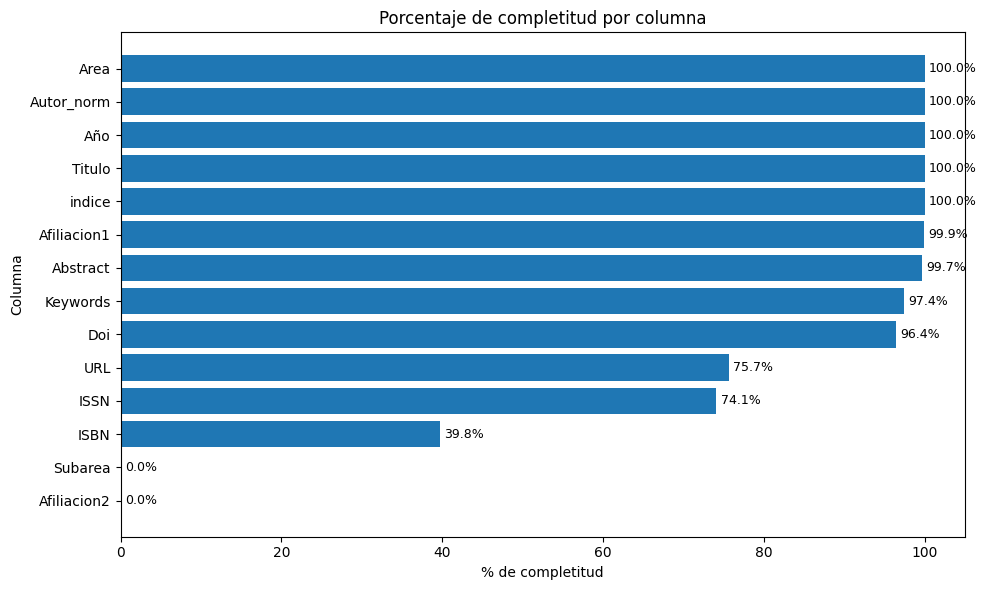

In [18]:
datos = perfil_completitud.sort_values("%_completitud", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(datos["columna"], datos["%_completitud"])
ax.set_title("Porcentaje de completitud por columna")
ax.set_xlabel("% de completitud")
ax.set_ylabel("Columna")
ax.set_xlim(0, 105)
agregar_etiquetas_barras(ax, orientacion="horizontal", formato="{:.1f}", sufijo="%")

guardar_grafica("01_completitud_por_columna.png")
plt.show()

### 11.2 Faltantes por columna

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\02_faltantes_por_columna.png


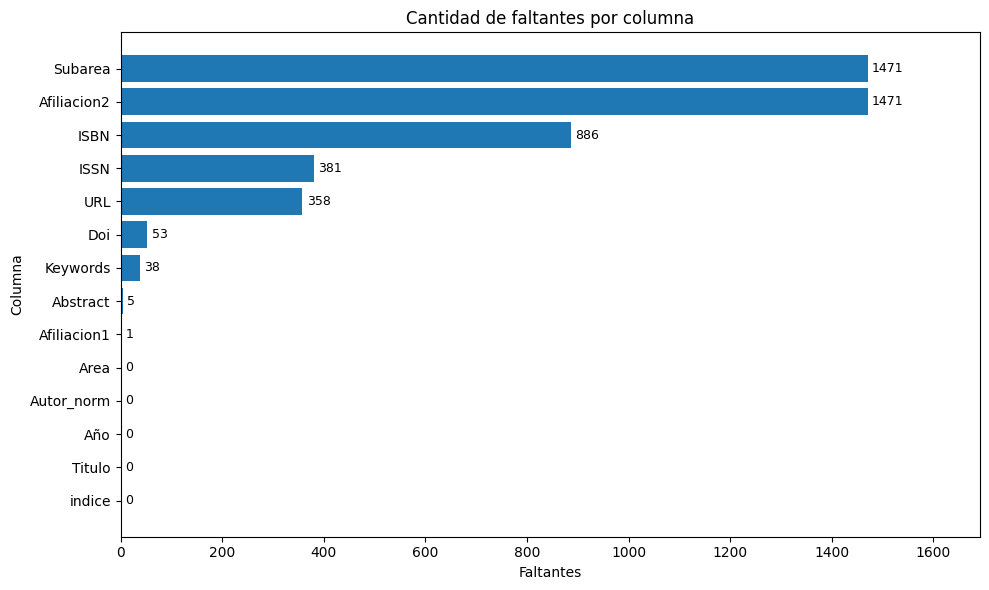

In [19]:
datos = perfil_completitud.sort_values("faltantes_total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(datos["columna"], datos["faltantes_total"])
ax.set_title("Cantidad de faltantes por columna")
ax.set_xlabel("Faltantes")
ax.set_ylabel("Columna")

maximo = max(datos["faltantes_total"].max(), 1)
ax.set_xlim(0, maximo * 1.15)
agregar_etiquetas_barras(ax, orientacion="horizontal", formato="{:.0f}")

guardar_grafica("02_faltantes_por_columna.png")
plt.show()

### 11.3 Registros por área

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\03_registros_por_area.png


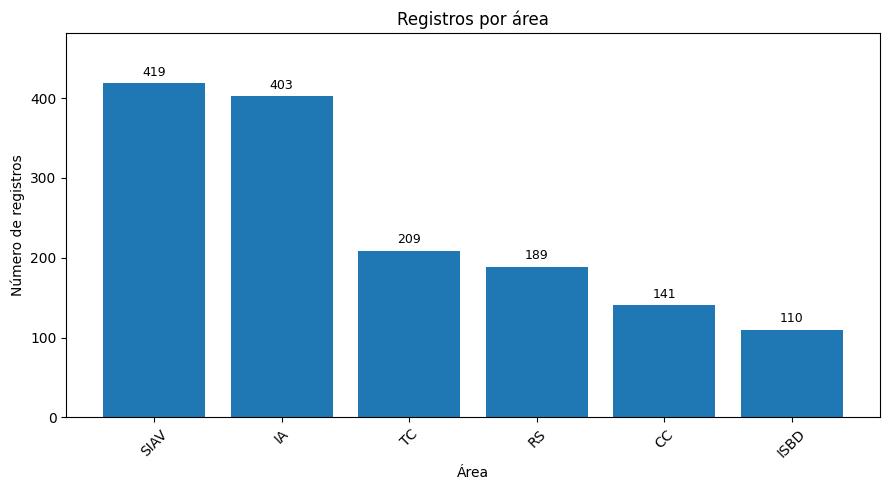

In [20]:
datos = conteos_area.sort_values("registros", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(datos["Area"], datos["registros"])
ax.set_title("Registros por área")
ax.set_xlabel("Área")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, max(datos["registros"].max(), 1) * 1.15)
agregar_etiquetas_barras(ax, formato="{:.0f}")

guardar_grafica("03_registros_por_area.png")
plt.show()

### 11.4 Registros por año

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\04_registros_por_anio.png


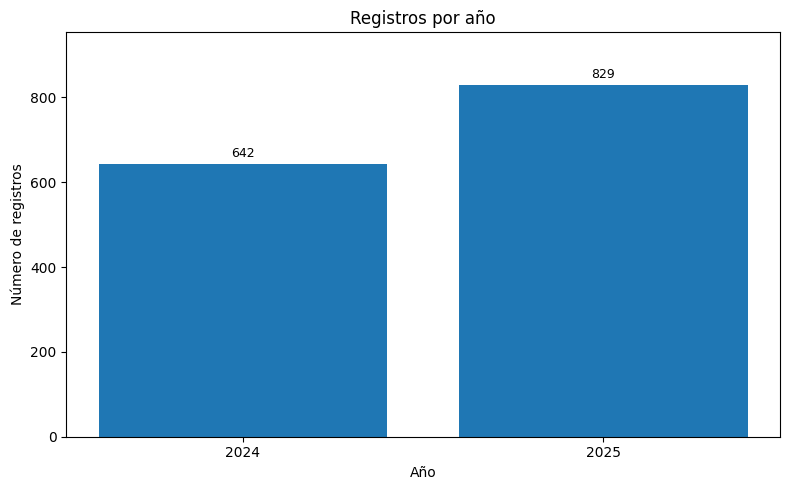

In [21]:
datos = conteos_anio.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(datos["Año"], datos["registros"])
ax.set_title("Registros por año")
ax.set_xlabel("Año")
ax.set_ylabel("Número de registros")
ax.set_ylim(0, max(datos["registros"].max(), 1) * 1.15)
agregar_etiquetas_barras(ax, formato="{:.0f}")

guardar_grafica("04_registros_por_anio.png")
plt.show()

### 11.5 Registros por fuente inferida

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\05_registros_por_fuente_inferida.png


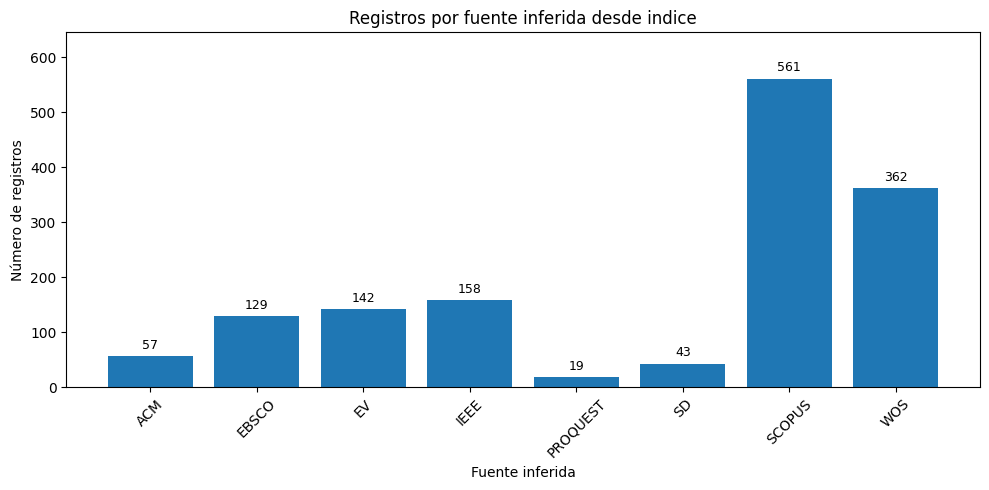

In [22]:
datos = conteos_fuente.copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(datos["fuente_inferida"], datos["registros"])
ax.set_title("Registros por fuente inferida desde indice")
ax.set_xlabel("Fuente inferida")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, max(datos["registros"].max(), 1) * 1.15)
agregar_etiquetas_barras(ax, formato="{:.0f}")

guardar_grafica("05_registros_por_fuente_inferida.png")
plt.show()

### 11.6 Área por fuente inferida

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\06_area_por_fuente_inferida.png


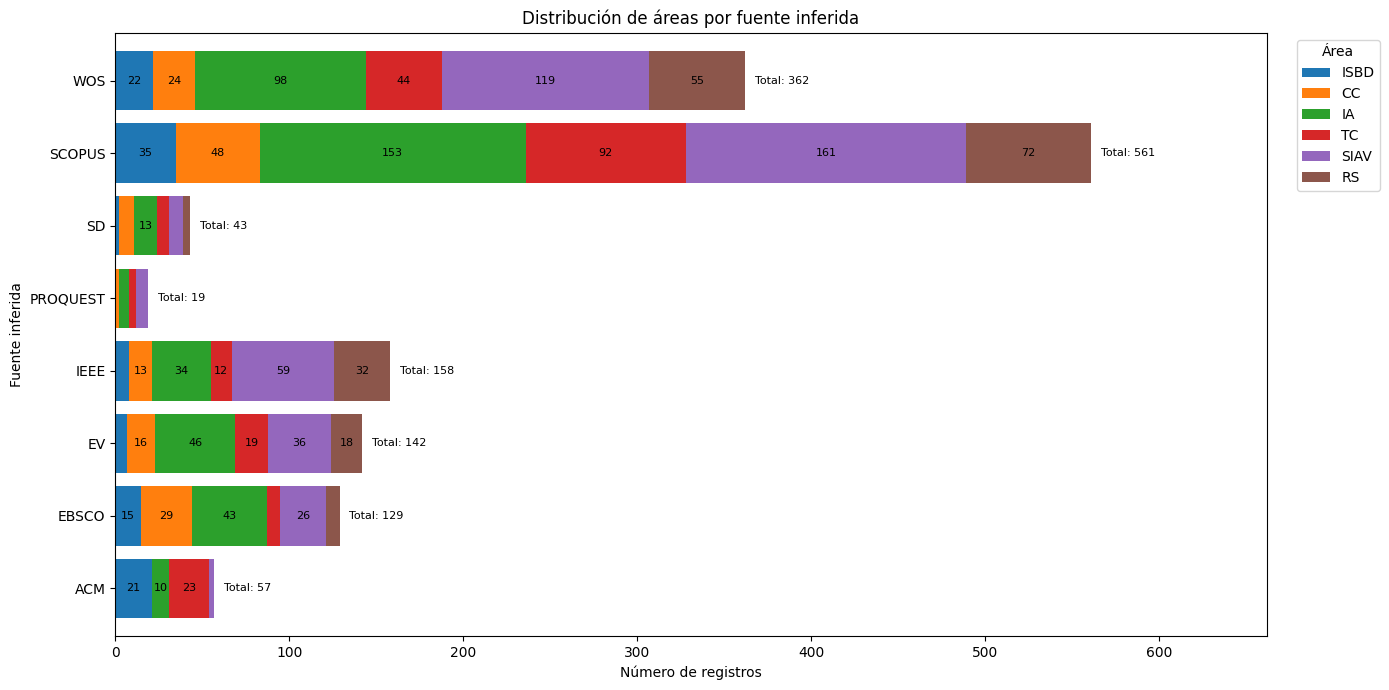

In [23]:
tabla_area_fuente = pd.crosstab(df_aux["fuente_inferida"], df_aux["area_grafica"])

# Ordenar filas y columnas para facilitar la lectura.
filas_ordenadas = [f for f in orden_fuentes_final if f in tabla_area_fuente.index]
columnas_ordenadas = [a for a in ["ISBD", "CC", "IA", "TC", "SIAV", "RS", "SIN_AREA"] if a in tabla_area_fuente.columns]
columnas_ordenadas += [a for a in tabla_area_fuente.columns if a not in columnas_ordenadas]

tabla_area_fuente = tabla_area_fuente.loc[filas_ordenadas, columnas_ordenadas]

fig, ax = plt.subplots(figsize=(14, 7))

# Barras horizontales apiladas: mejor lectura y menos traslape.
tabla_area_fuente.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    width=0.82
)

ax.set_title("Distribución de áreas por fuente inferida")
ax.set_xlabel("Número de registros")
ax.set_ylabel("Fuente inferida")
ax.legend(title="Área", bbox_to_anchor=(1.02, 1), loc="upper left")

# Etiquetar solo segmentos suficientemente grandes.
# Los segmentos pequeños siguen representados por el color, pero no se saturan con texto.
umbral_etiqueta = 10

for contenedor in ax.containers:
    for barra in contenedor:
        valor = barra.get_width()
        if valor >= umbral_etiqueta:
            x = barra.get_x() + valor / 2
            y = barra.get_y() + barra.get_height() / 2
            ax.text(
                x,
                y,
                f"{int(valor)}",
                ha="center",
                va="center",
                fontsize=8
            )

# Agregar total al final de cada barra.
totales = tabla_area_fuente.sum(axis=1)
max_total = totales.max()

for i, total in enumerate(totales):
    ax.text(
        total + max_total * 0.01,
        i,
        f"Total: {int(total)}",
        va="center",
        fontsize=8
    )

# Dar espacio a las etiquetas de total.
ax.set_xlim(0, max_total * 1.18)

plt.tight_layout()
guardar_grafica("06_area_por_fuente_inferida.png")
plt.show()

### 11.7 Fallas de reglas básicas

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\07_fallas_reglas_basicas.png


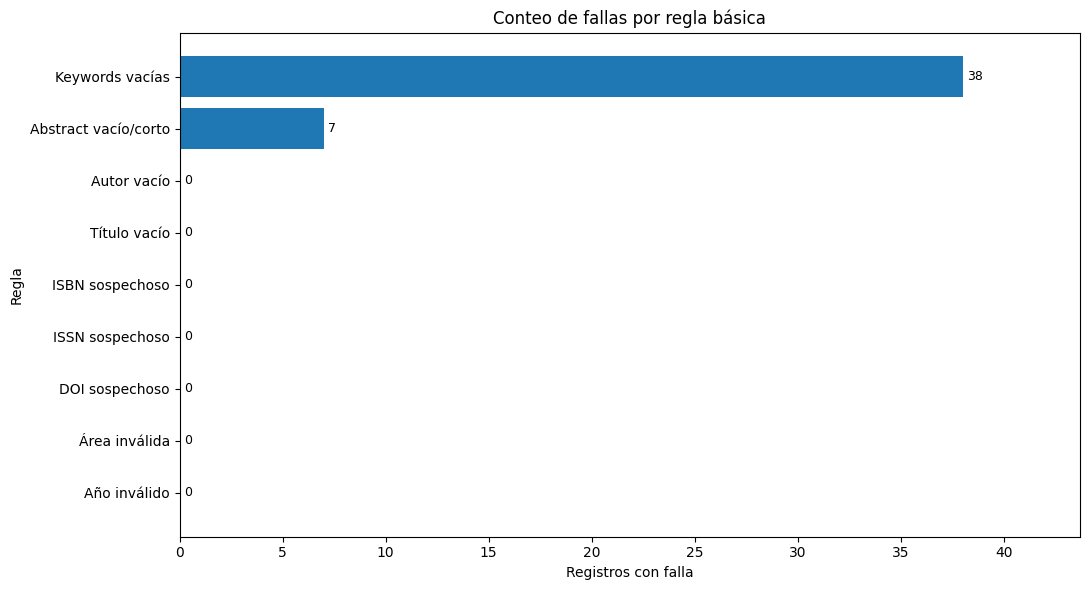

In [24]:
datos = resumen_fallas.sort_values("conteo", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(datos["regla"], datos["conteo"])
ax.set_title("Conteo de fallas por regla básica")
ax.set_xlabel("Registros con falla")
ax.set_ylabel("Regla")
ax.set_xlim(0, max(datos["conteo"].max(), 1) * 1.15)
agregar_etiquetas_barras(ax, orientacion="horizontal", formato="{:.0f}")

guardar_grafica("07_fallas_reglas_basicas.png")
plt.show()

### 11.8 Posibles duplicados

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\08_posibles_duplicados.png


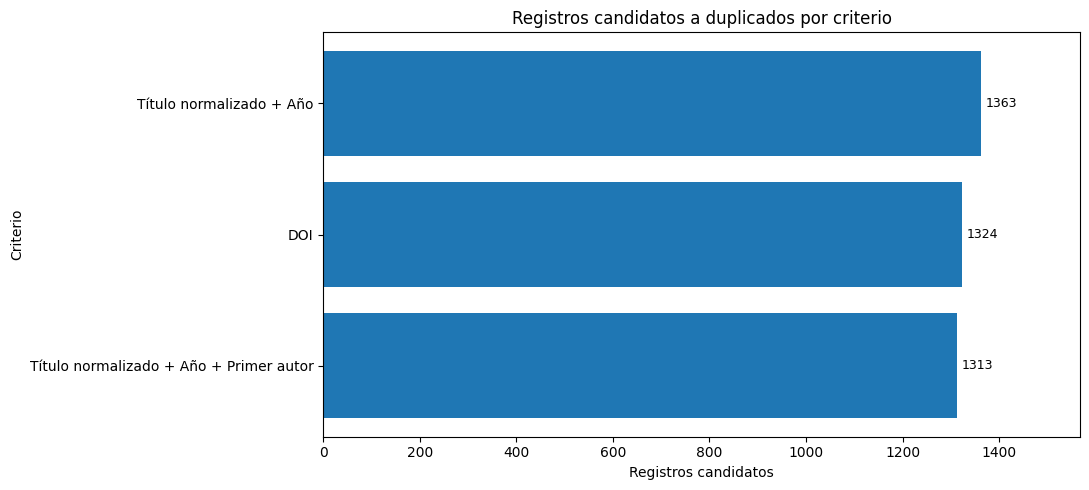

In [25]:
datos = resumen_duplicados.sort_values("registros_candidatos", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(datos["criterio"], datos["registros_candidatos"])
ax.set_title("Registros candidatos a duplicados por criterio")
ax.set_xlabel("Registros candidatos")
ax.set_ylabel("Criterio")
ax.set_xlim(0, max(datos["registros_candidatos"].max(), 1) * 1.15)
agregar_etiquetas_barras(ax, orientacion="horizontal", formato="{:.0f}")

guardar_grafica("08_posibles_duplicados.png")
plt.show()

### 11.9 Longitud de títulos

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\09_longitud_titulos.png


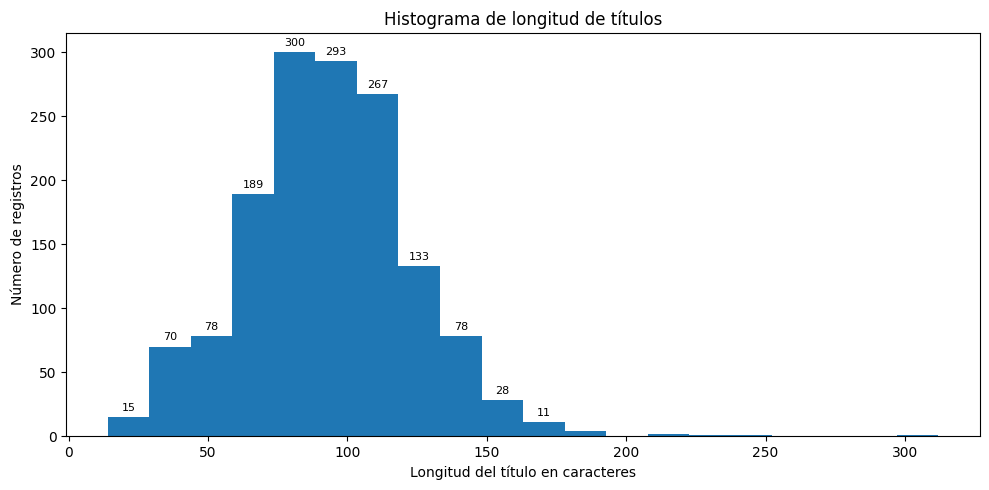

In [26]:
valores = df_aux["longitud_titulo"]

fig, ax = plt.subplots(figsize=(10, 5))
counts, bins, patches = ax.hist(valores, bins=20)
ax.set_title("Histograma de longitud de títulos")
ax.set_xlabel("Longitud del título en caracteres")
ax.set_ylabel("Número de registros")
agregar_etiquetas_histograma(ax, counts, patches)

guardar_grafica("09_longitud_titulos.png")
plt.show()

### 11.10 Longitud de abstracts

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\10_longitud_abstracts.png


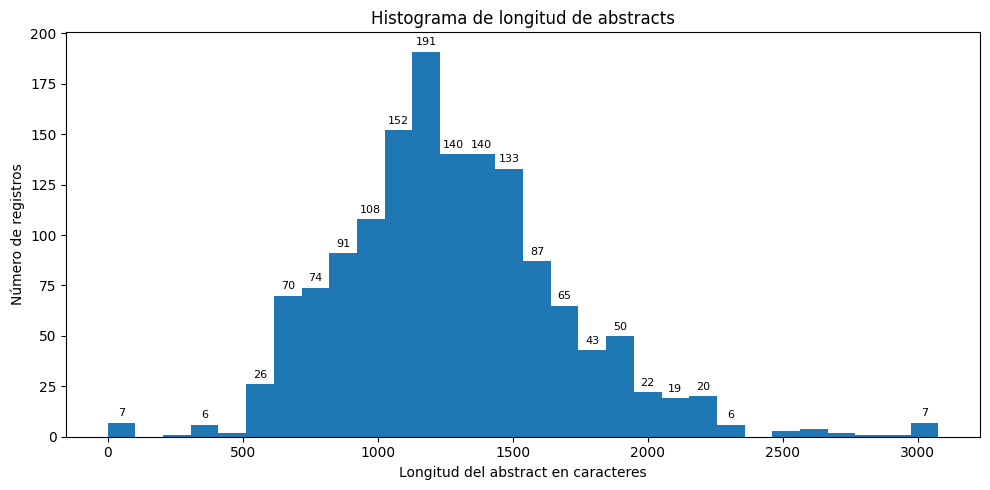

In [27]:
valores = df_aux["longitud_abstract"]

fig, ax = plt.subplots(figsize=(10, 5))
counts, bins, patches = ax.hist(valores, bins=30)
ax.set_title("Histograma de longitud de abstracts")
ax.set_xlabel("Longitud del abstract en caracteres")
ax.set_ylabel("Número de registros")
agregar_etiquetas_histograma(ax, counts, patches)

guardar_grafica("10_longitud_abstracts.png")
plt.show()

### 11.11 Top keywords frecuentes

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\11_top_keywords_frecuentes.png


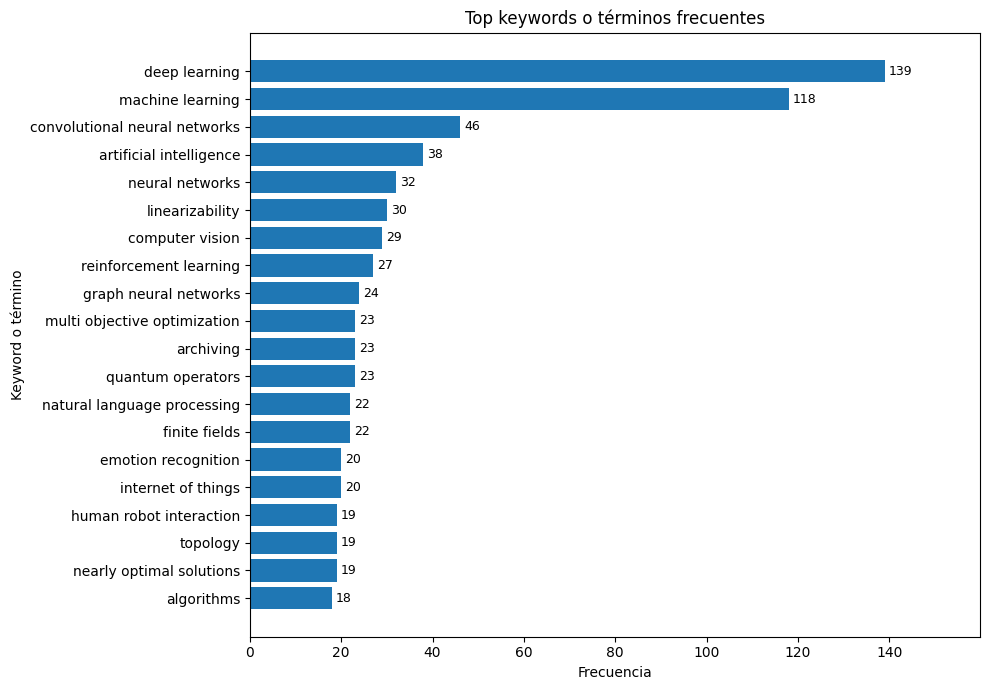

In [28]:
top_keywords = conteo_keywords_frecuentes.head(20)

fig, ax = plt.subplots(figsize=(10, 7))

if top_keywords.empty:
    ax.text(0.5, 0.5, "No se encontraron keywords no vacías.", ha="center", va="center")
    ax.set_axis_off()
else:
    datos = top_keywords.sort_values(ascending=True)
    ax.barh(datos.index, datos.values)
    ax.set_title("Top keywords o términos frecuentes")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Keyword o término")
    ax.set_xlim(0, max(datos.max(), 1) * 1.15)
    agregar_etiquetas_barras(ax, orientacion="horizontal", formato="{:.0f}")

guardar_grafica("11_top_keywords_frecuentes.png")
plt.show()

### 11.12 Problemas textuales

Gráfica guardada: C:\Users\hazar\Desktop\PROYECTO\10_visualizaciones\perfilado\12_problemas_textuales.png


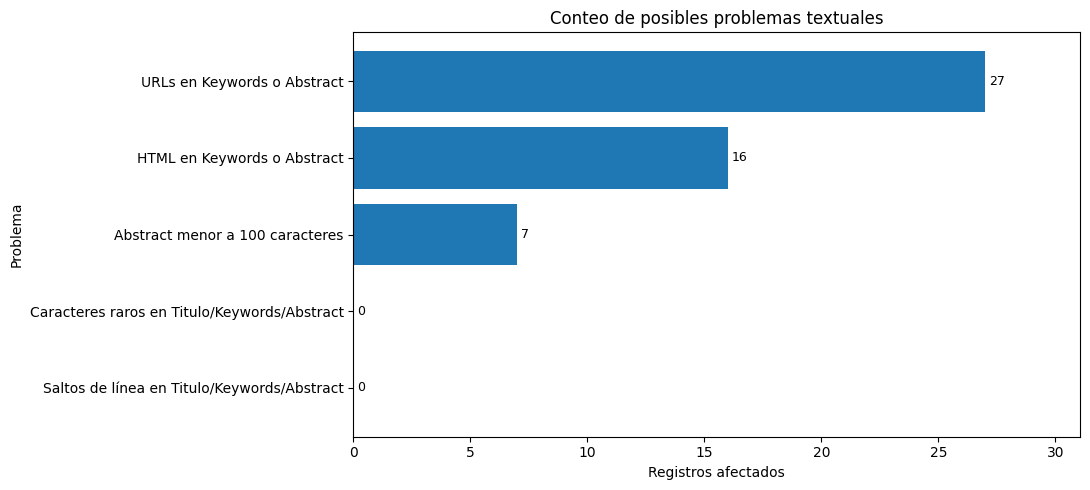

In [29]:
resumen_problemas_textuales = pd.DataFrame([
    {"problema": "URLs en Keywords o Abstract", "conteo": int(mask_url_en_keywords_o_abstract.sum())},
    {"problema": "HTML en Keywords o Abstract", "conteo": int(mask_html_en_keywords_o_abstract.sum())},
    {"problema": "Saltos de línea en Titulo/Keywords/Abstract", "conteo": int(mask_saltos_linea_texto.sum())},
    {"problema": "Caracteres raros en Titulo/Keywords/Abstract", "conteo": int(mask_caracteres_raros_texto.sum())},
    {"problema": f"Abstract menor a {UMBRAL_ABSTRACT_CORTO} caracteres", "conteo": int(mask_abstract_vacio_o_corto.sum())},
]).sort_values("conteo", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(resumen_problemas_textuales["problema"], resumen_problemas_textuales["conteo"])
ax.set_title("Conteo de posibles problemas textuales")
ax.set_xlabel("Registros afectados")
ax.set_ylabel("Problema")
ax.set_xlim(0, max(resumen_problemas_textuales["conteo"].max(), 1) * 1.15)
agregar_etiquetas_barras(ax, orientacion="horizontal", formato="{:.0f}")

guardar_grafica("12_problemas_textuales.png")
plt.show()

## 12. Conclusión provisional

Esta conclusión es automática y sirve solo para orientar la revisión manual posterior.  
No se crean reportes finales ni reglas de limpieza en esta etapa.

In [30]:
columnas_mas_faltantes = (
    perfil_completitud
    .sort_values("faltantes_total", ascending=False)
    .head(5)
)

reglas_mas_fallas = (
    resumen_fallas
    .sort_values("conteo", ascending=False)
    .head(5)
)

campos_revision = set()

for _, fila in columnas_mas_faltantes.iterrows():
    if fila["faltantes_total"] > 0:
        campos_revision.add(fila["columna"])

if mask_anio_invalido.any():
    campos_revision.add("Año")
if mask_area_invalida.any():
    campos_revision.add("Area")
if mask_doi_sospechoso.any():
    campos_revision.add("Doi")
if mask_issn_sospechoso.any():
    campos_revision.add("ISSN")
if mask_isbn_sospechoso.any():
    campos_revision.add("ISBN")
if mask_titulo_vacio.any() or mask_saltos_linea_texto.any() or mask_caracteres_raros_texto.any():
    campos_revision.add("Titulo")
if mask_autor_vacio.any():
    campos_revision.add("Autor_norm")
if mask_afiliacion_vacia.any() or mask_afiliacion_sin_evidencia_unam.any():
    campos_revision.add("Afiliacion1/Afiliacion2")
if mask_abstract_vacio_o_corto.any() or mask_url_en_keywords_o_abstract.any() or mask_html_en_keywords_o_abstract.any():
    campos_revision.add("Abstract")
if mask_keywords_vacias.any() or mask_url_en_keywords_o_abstract.any() or mask_html_en_keywords_o_abstract.any():
    campos_revision.add("Keywords")

print("Hallazgos automáticos provisionales")
print("-" * 45)
print(f"• Total de filas: {len(df):,}")
print(f"• Total de columnas: {len(df.columns):,}")
print(
    "• Columnas con más faltantes: "
    + "; ".join(
        f"{fila['columna']} ({int(fila['faltantes_total']):,})"
        for _, fila in columnas_mas_faltantes.iterrows()
    )
)
print(
    "• Reglas con más fallas: "
    + "; ".join(
        f"{fila['regla']} ({int(fila['conteo']):,})"
        for _, fila in reglas_mas_fallas.iterrows()
    )
)
print(f"• Registros candidatos duplicados por DOI: {int(mask_dup_doi.sum()):,}")
print(f"• Registros candidatos duplicados por título normalizado + año: {int(mask_dup_titulo_anio.sum()):,}")
print(
    "• Registros candidatos duplicados por título normalizado + año + primer autor: "
    f"{int(mask_dup_titulo_anio_autor.sum()):,}"
)
print(
    "• Campos que requieren revisión manual: "
    + (", ".join(sorted(campos_revision)) if campos_revision else "Ninguno según estas reglas básicas")
)

print("\nNota: esta libreta solo diagnostica. No limpia, elimina, deduplica, fusiona ni exporta reportes finales.")

Hallazgos automáticos provisionales
---------------------------------------------
• Total de filas: 1,471
• Total de columnas: 14
• Columnas con más faltantes: Afiliacion2 (1,471); Subarea (1,471); ISBN (886); ISSN (381); URL (358)
• Reglas con más fallas: Keywords vacías (38); Abstract vacío/corto (7); Año inválido (0); Área inválida (0); DOI sospechoso (0)
• Registros candidatos duplicados por DOI: 1,324
• Registros candidatos duplicados por título normalizado + año: 1,363
• Registros candidatos duplicados por título normalizado + año + primer autor: 1,313
• Campos que requieren revisión manual: Abstract, Afiliacion1/Afiliacion2, Afiliacion2, ISBN, ISSN, Keywords, Subarea, URL

Nota: esta libreta solo diagnostica. No limpia, elimina, deduplica, fusiona ni exporta reportes finales.
